# Estimation Risk in Mean-Variance Portfolio Optimization: U.S. Sector ETFs

**Question:** How much should a portfolio manager trust a mean-variance optimizer built on historical data, and what happens when its outputs are used to allocate real capital?

**Data:** Daily adjusted prices for the 11 SPDR sector ETFs plus SPY (June 2018 – September 2026), pulled from Yahoo Finance via `yfinance`.

**Outline:**
1. **Data pipeline:** reproducible, cached price ingestion and return construction
2. **Parameter and model uncertainty:** simulation, CAPM vs. sample moments, bootstrap, rolling windows, and dimensionality
3. **Weight sensitivity:** how optimal weights respond to risk aversion, expected returns, correlations, volatility, and constraints
4. **Rebalancing and trading costs:** out-of-sample performance under realistic frictions
5. **Walk-forward backtest:** a full rolling re-estimation strategy, a performance tearsheet, and a recommendation to the portfolio manager

**Bottom line:** An unconstrained optimizer turns noisy estimates, especially of expected returns, into extreme, unstable positions. The walk-forward strategy underperforms both passive benchmarks on a risk-adjusted basis (Sharpe 0.19 vs. 0.76 equal-weight and 0.85 SPY). The recommendation is not to fund it without leverage constraints and shrinkage estimators.


## Section 1 — Data Pipeline

This section builds a reproducible pipeline for fetching and caching daily price data for the 12 tickers (11 SPDR sector ETFs + SPY). Design decisions:

- **Adjusted close**: prices are pulled via yfinance's default `auto_adjust=True` behavior, so the `Close` column returned already reflects dividend and split-adjusted prices.
- **Return convention**: **simple (percent) returns** are used throughout this notebook, computed as `P_t / P_{t-1} - 1`. This choice is made because portfolio-level returns in Sections 4 and 5 are computed as a weighted sum of asset returns, which is only mathematically exact for simple returns (log returns aggregate correctly across time, not across assets).
- **Sample window**: the sample start date is determined empirically below, by checking the earliest date each ticker actually has data for in yfinance, and constraining the whole universe to start on the date of the youngest ticker. This keeps the resulting DataFrame fully rectangular (no missing tickers on any date) without needing special-case handling.
- **Caching**: prices are cached to a local CSV file in a `data/` folder created relative to the notebook. On each call, the cache is checked against the most recent completed NYSE trading session (via `pandas_market_calendars`); if the cache does not yet cover that session, the full date range is re-downloaded and the cache file is overwritten.

In [1]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_market_calendars as mcal

In [2]:
TICKERS = ["XLC", "XLY", "XLP", "XLE", "XLF", "XLV", "XLI", "XLB", "XLRE", "XLK", "XLU", "SPY"]

CACHE_DIR = "./data"
CACHE_PATH = os.path.join(CACHE_DIR, "prices_cache.csv")

### Determining the sample start date

Not all tickers in this universe have existed for the same length of time. To determine the correct sample start date empirically (using the same data source and adjustment method as the rest of this pipeline) each ticker is queried individually from an early date, and its first available date is recorded. The sample start is then set to the *latest* of these first-available dates, i.e., the listing date of the youngest ticker, so that the full universe has data on every date used in the notebook.

In [3]:
first_dates = {}

for ticker in TICKERS:
    hist = yf.download(ticker, start="1990-01-01", progress=False)
    close_series = hist["Close"][ticker]  
    first_dates[ticker] = close_series.first_valid_index()

first_dates_series = pd.Series(first_dates).sort_values()
print(first_dates_series)

SAMPLE_START = first_dates_series.max()
print("\nSample start date (youngest ticker constrains the universe):", SAMPLE_START)

SPY    1993-01-29
XLY    1998-12-22
XLP    1998-12-22
XLE    1998-12-22
XLF    1998-12-22
XLV    1998-12-22
XLI    1998-12-22
XLB    1998-12-22
XLK    1998-12-22
XLU    1998-12-22
XLRE   2015-10-08
XLC    2018-06-19
dtype: datetime64[s]

Sample start date (youngest ticker constrains the universe): 2018-06-19 00:00:00


In [4]:
def get_last_available_trading_day():
    """
    Returns the most recent NYSE trading session that has already
    fully completed, as a pandas Timestamp (normalized to midnight,
    matching how dates will be stored/compared elsewhere).
    """
    nyse = mcal.get_calendar("NYSE")
    today = pd.Timestamp.today().normalize()

    schedule = nyse.schedule(start_date=today - pd.Timedelta(days=10), end_date=today)
    valid_sessions = schedule.index

    now = pd.Timestamp.now(tz="America/New_York")
    market_close_today = schedule.loc[schedule.index == today, "market_close"] if today in valid_sessions else None

    if today in valid_sessions and market_close_today is not None and len(market_close_today) > 0:
        if now >= market_close_today.iloc[0]:
            return today

    completed_sessions = valid_sessions[valid_sessions < today]
    return completed_sessions.max()

In [5]:
def download_prices(start_date, end_date):
    """
    Downloads adjusted close prices for all TICKERS from start_date
    through end_date (inclusive), returns a wide DataFrame:
    dates as index, tickers as columns.
    """
    raw = yf.download(TICKERS, start=start_date, end=end_date + pd.Timedelta(days=1),
                       progress=False)

    close = raw["Close"]  
    close = close[TICKERS] 
    close.index.name = "Date"

    return close

In [6]:
def load_prices():
    """
    Returns a DataFrame of adjusted close prices for all TICKERS,
    reading from a local CSV cache when it is already up to date,
    and downloading (then caching) fresh data otherwise.
    """
    os.makedirs(CACHE_DIR, exist_ok=True)
    target_date = get_last_available_trading_day()

    if os.path.exists(CACHE_PATH):
        cached = pd.read_csv(CACHE_PATH, index_col="Date", parse_dates=["Date"])
        cache_last_date = cached.index.max()

        if cache_last_date >= target_date:
            return cached

    fresh = download_prices(SAMPLE_START, target_date)
    fresh.to_csv(CACHE_PATH)
    return fresh

Fetching (or loading cached) adjusted close prices for all 12 tickers:

In [7]:
prices = load_prices()

print(prices.shape)
print(prices.index.min(), "to", prices.index.max())
prices.head()

(2066, 12)
2018-06-19 00:00:00 to 2026-09-08 00:00:00


Ticker,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU,SPY
Date,,,,,,,,,,,,
2018-06-19,46.204102,51.813148,41.185303,26.374029,23.501102,74.017876,64.095222,24.884983,24.024590,33.140591,19.561113,243.921692
2018-06-20,46.777496,52.058811,41.225632,26.490477,23.440948,74.174904,64.138985,24.804146,24.283903,33.210190,19.576700,244.337814
2018-06-21,46.490799,51.687977,41.306293,25.999985,23.372204,73.747467,63.333755,24.540361,24.428810,32.955002,19.642960,242.806122
2018-06-22,46.694260,51.599903,41.645058,26.518705,23.260502,74.078926,63.552570,24.897747,24.642359,32.848293,19.779366,243.248779
2018-06-25,45.732460,50.478176,41.854778,25.985853,23.011307,73.398613,62.747341,24.510584,24.581347,32.166283,20.106750,239.937500


### Converting prices to returns

Daily simple returns are computed as `P_t / P_{t-1} - 1` for each ticker. The first row (undefined by construction) is dropped.

In [8]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU,SPY
Date,,,,,,,,,,,,
2018-06-20,0.012410,0.004741,0.000979,0.004415,-0.002560,0.002121,0.000683,-0.003248,0.010794,0.002100,0.000797,0.001706
2018-06-21,-0.006129,-0.007123,0.001957,-0.018516,-0.002933,-0.005763,-0.012554,-0.010635,0.005967,-0.007684,0.003385,-0.006269
2018-06-22,0.004376,-0.001704,0.008201,0.019951,-0.004779,0.004495,0.003455,0.014563,0.008742,-0.003238,0.006944,0.001823
2018-06-25,-0.020598,-0.021739,0.005036,-0.020093,-0.010713,-0.009184,-0.012670,-0.015550,-0.002476,-0.020762,0.016552,-0.013613
2018-06-26,0.001658,0.007162,-0.004240,0.012629,-0.003361,-0.003090,0.003766,0.003819,0.005275,0.004038,0.001163,0.002214


In [9]:
print("Shape:", returns.shape)
print("Any NaNs left?", returns.isna().sum().sum())
print("Date range:", returns.index.min(), "to", returns.index.max())

Shape: (2065, 12)
Any NaNs left? 0
Date range: 2018-06-20 00:00:00 to 2026-09-08 00:00:00


## Section 2 — Parameter and Model Uncertainty

### 2.1 — Simulation Study (No Model Risk)

To measure how reliable our estimates of `mu` and `Sigma` are, we need a setting where the "true" parameters are known. Here, the full-sample sample mean and sample covariance from the real sector ETF data are treated as ground truth (`mu_star`, `Sigma_star`). Synthetic samples of varying size `n` are then drawn from `N(mu_star, Sigma_star)`, and the estimation error of the resulting `mu_hat`/`Sigma_hat` is measured against the known truth, across 1000 independent replicates per `n`. This isolates pure sampling/estimation error, there is no model misspecification here since the data-generating process is exactly the assumed multivariate normal.

In [10]:
np.random.seed(42)

mu_star = returns.mean().values
Sigma_star = returns.cov().values

print("mu_star:")
print(pd.Series(mu_star, index=returns.columns))
print("\nSigma_star:")
print(pd.DataFrame(Sigma_star, index=returns.columns, columns=returns.columns))

mu_star:
Ticker
XLC     0.000524
XLY     0.000495
XLP     0.000394
XLE     0.000636
XLF     0.000539
XLV     0.000455
XLI     0.000575
XLB     0.000452
XLRE    0.000387
XLK     0.000983
XLU     0.000469
SPY     0.000627
dtype: float64

Sigma_star:
Ticker       XLC       XLY       XLP       XLE       XLF       XLV       XLI  \
Ticker                                                                         
XLC     0.000194  0.000169  0.000073  0.000115  0.000135  0.000094  0.000125   
XLY     0.000169  0.000226  0.000079  0.000131  0.000157  0.000101  0.000153   
XLP     0.000073  0.000079  0.000097  0.000076  0.000087  0.000077  0.000081   
XLE     0.000115  0.000131  0.000076  0.000398  0.000194  0.000096  0.000171   
XLF     0.000135  0.000157  0.000087  0.000194  0.000214  0.000107  0.000169   
XLV     0.000094  0.000101  0.000077  0.000096  0.000107  0.000121  0.000101   
XLI     0.000125  0.000153  0.000081  0.000171  0.000169  0.000101  0.000180   
XLB     0.000125  0.000151  0.00

In [11]:
sample_sizes = [63, 126, 252, 504, 1008, 2520]
n_replicates = 1000
n_assets = len(returns.columns)
asset_names = returns.columns.tolist()

In [12]:
results = []

# pick a couple of specific entries to track individually for later distribution plots
tracked_assets = ["XLK", "XLU", "XLE"]
tracked_pair = ("XLK", "XLU")

for n in sample_sizes:
    for rep in range(n_replicates):
        sample = np.random.multivariate_normal(mean=mu_star, cov=Sigma_star, size=n)

        mu_hat = sample.mean(axis=0)
        Sigma_hat = np.cov(sample, rowvar=False)

        mu_rmse = np.sqrt(np.mean((mu_hat - mu_star) ** 2))
        sigma_frobenius = np.linalg.norm(Sigma_hat - Sigma_star, ord="fro")

        row = {
            "n": n,
            "replicate": rep,
            "mu_rmse": mu_rmse,
            "sigma_frobenius": sigma_frobenius,
        }

        for asset in tracked_assets:
            idx = asset_names.index(asset)
            row[f"mu_hat_{asset}"] = mu_hat[idx]

        i, j = asset_names.index(tracked_pair[0]), asset_names.index(tracked_pair[1])
        row[f"sigma_hat_{tracked_pair[0]}_{tracked_pair[1]}"] = Sigma_hat[i, j]

        results.append(row)

results_df = pd.DataFrame(results)
results_df.head()

,n,replicate,mu_rmse,sigma_frobenius,mu_hat_XLK,mu_hat_XLU,mu_hat_XLE,sigma_hat_XLK_XLU
0,63,0,0.001498,0.000408,0.000670,-0.000160,-0.003424,0.000031
1,63,1,0.002351,0.000589,-0.000681,-0.001052,0.000862,0.000046
2,63,2,0.001519,0.000450,0.000588,0.003222,0.003609,0.000083
3,63,3,0.001077,0.000320,0.000215,-0.001326,-0.000419,0.000128
4,63,4,0.001162,0.000252,-0.000243,0.000213,0.000380,0.000061


In [13]:
summary = results_df.groupby("n")[["mu_rmse", "sigma_frobenius"]].agg(["mean", "median", "std"])
summary

mu_rmse                     sigma_frobenius                    
          mean    median       std            mean    median       std
n                                                                     
63    0.001594  0.001441  0.000687        0.000341  0.000309  0.000136
126   0.001168  0.001046  0.000523        0.000245  0.000222  0.000097
252   0.000822  0.000738  0.000361        0.000167  0.000151  0.000066
504   0.000573  0.000522  0.000259        0.000122  0.000110  0.000048
1008  0.000402  0.000354  0.000179        0.000087  0.000078  0.000033
2520  0.000265  0.000237  0.000125        0.000054  0.000049  0.000023

In [14]:
mu_relative_error = summary[("mu_rmse", "mean")] / np.mean(np.abs(mu_star))
sigma_relative_error = summary[("sigma_frobenius", "mean")] / np.linalg.norm(Sigma_star, ord="fro")

comparison = pd.DataFrame({
    "mu_relative_error": mu_relative_error,
    "sigma_relative_error": sigma_relative_error
})
comparison

,mu_relative_error,sigma_relative_error
n,,
63,2.926056,0.208032
126,2.143592,0.149307
252,1.508799,0.102017
504,1.051086,0.074492
1008,0.738061,0.052788
2520,0.486926,0.033205


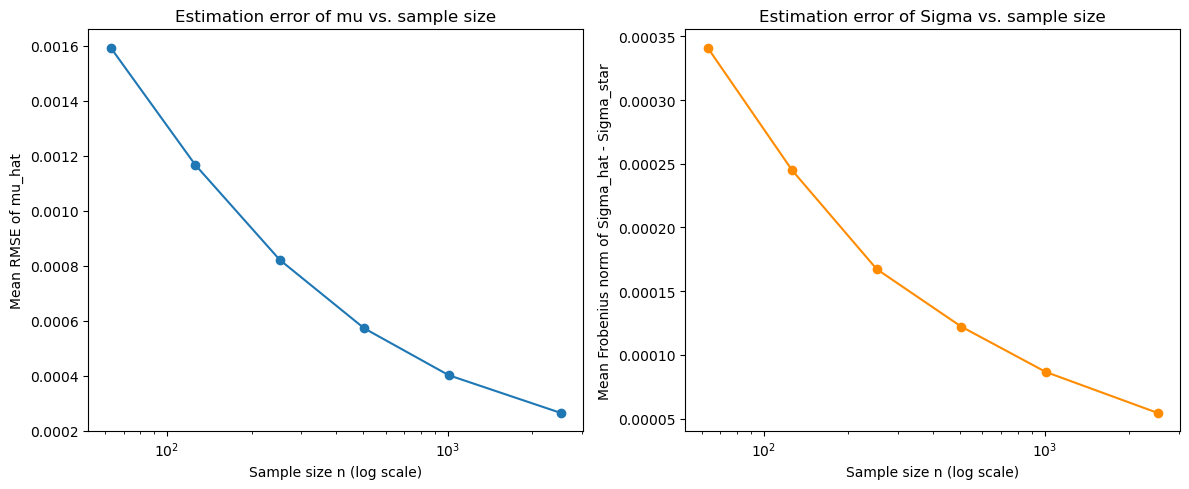

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mu_means = results_df.groupby("n")["mu_rmse"].mean()
sigma_means = results_df.groupby("n")["sigma_frobenius"].mean()

axes[0].plot(mu_means.index, mu_means.values, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("Sample size n (log scale)")
axes[0].set_ylabel("Mean RMSE of mu_hat")
axes[0].set_title("Estimation error of mu vs. sample size")

axes[1].plot(sigma_means.index, sigma_means.values, marker="o", color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("Sample size n (log scale)")
axes[1].set_ylabel("Mean Frobenius norm of Sigma_hat - Sigma_star")
axes[1].set_title("Estimation error of Sigma vs. sample size")

plt.tight_layout()
plt.show()

At the shortest sample size tested (n=63), the mean RMSE of mu_hat is 0.00159 which is nearly three times the average magnitude of mu_star itself, meaning a quarter's worth of data provides essentially no reliable signal about expected returns. Even at n=2520 (ten years of daily data), mu's RMSE has fallen to 0.000265, but this is still 48% of mu_star's typical magnitude. A full decade of history still leaves substantial uncertainty in the mean estimate. Sigma tells a different story in relative terms: its Frobenius-norm error starts at 0.000341 at n=63 and falls to 0.000054 by n=2520, an order of magnitude more precise, relatively, than mu at every sample size tested. In absolute terms both errors shrink at a similar rate (roughly 6x over a 40x increase in n, consistent with the theoretical √n convergence of sample estimators), but because mu's true signal is so small relative to its own sampling noise, this shared convergence rate leaves mu far less reliable in practice. For this universe, Sigma-based inputs become reasonably trustworthy by n≈252–504, while raw historical mu estimates remain unreliable even with a full decade of data.

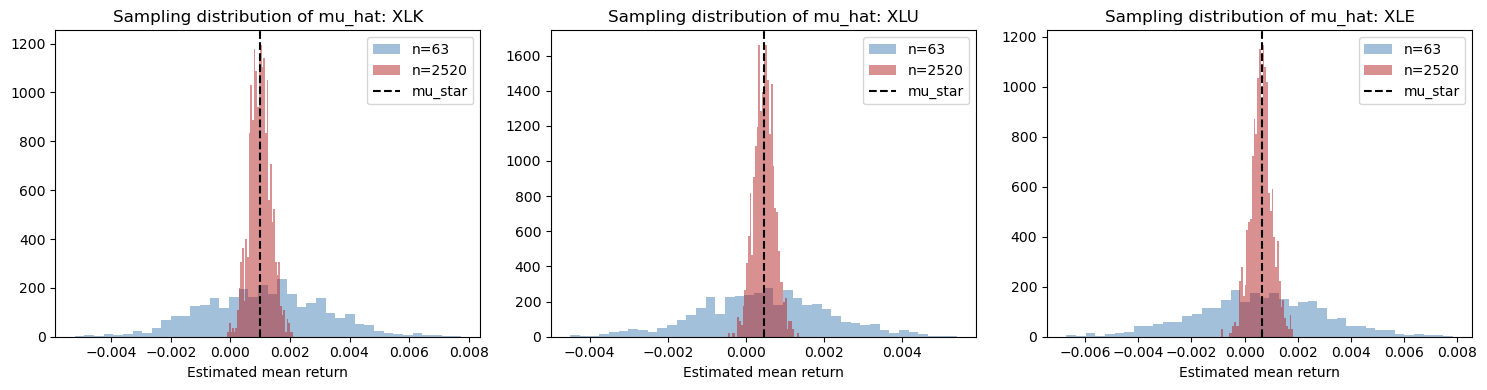

In [16]:
fig, axes = plt.subplots(1, len(tracked_assets), figsize=(15, 4), sharey=False)

compare_ns = [63, 2520]
colors = ["steelblue", "firebrick"]

for ax, asset in zip(axes, tracked_assets):
    for n_val, color in zip(compare_ns, colors):
        subset = results_df[results_df["n"] == n_val][f"mu_hat_{asset}"]
        ax.hist(subset, bins=40, alpha=0.5, label=f"n={n_val}", color=color, density=True)

    true_val = mu_star[asset_names.index(asset)]
    ax.axvline(true_val, color="black", linestyle="--", label="mu_star")
    ax.set_title(f"Sampling distribution of mu_hat: {asset}")
    ax.set_xlabel("Estimated mean return")
    ax.legend()

plt.tight_layout()
plt.show()

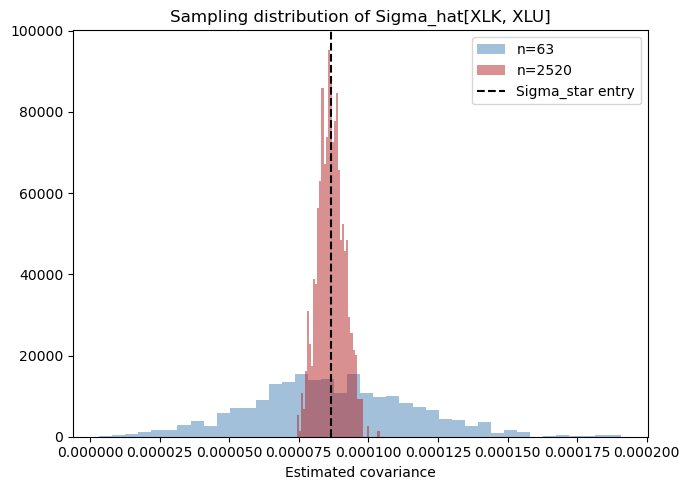

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

col_name = f"sigma_hat_{tracked_pair[0]}_{tracked_pair[1]}"
true_val = Sigma_star[asset_names.index(tracked_pair[0]), asset_names.index(tracked_pair[1])]

for n_val, color in zip(compare_ns, colors):
    subset = results_df[results_df["n"] == n_val][col_name]
    ax.hist(subset, bins=40, alpha=0.5, label=f"n={n_val}", color=color, density=True)

ax.axvline(true_val, color="black", linestyle="--", label="Sigma_star entry")
ax.set_title(f"Sampling distribution of Sigma_hat[{tracked_pair[0]}, {tracked_pair[1]}]")
ax.set_xlabel("Estimated covariance")
ax.legend()
plt.tight_layout()
plt.show()

This narrowing is also visible directly in the sampling distributions: mu_hat for XLK, XLU, and XLE is spread widely around mu_star at n=63 but collapses into a tighter band by n=2520, and the same pattern holds for the Sigma_hat[XLK, XLU] covariance estimate, which is noticeably more concentrated around Sigma_star even at n=63 than any of the mu_hat distributions are.

### 2.2 — Model Uncertainty on Real Data

Two estimation approaches are compared on the real sector ETF returns (SPY excluded from the investable universe as it is used only as the CAPM market factor and, later, as a passive benchmark):

1. **Sample moments**: the sample mean vector and sample covariance matrix, computed directly from the 11 sectors' return history. No structural assumptions, each pairwise covariance freely estimated.
2. **CAPM**: a single-factor model with SPY as the market factor, estimated for all 11 sectors at once via matrix OLS: `Y = X @ B + resid`, where `Y` is the (n x 11) matrix of sector returns and `X = [1, r_SPY]` is (n x 2). The resulting coefficient matrix `B` contains each sector's alpha and beta. Using the law of total expectation and law of total covariance (conditioning on the market return), the implied moments are reconstructed as:

   - `mu_capm = B.T @ [1, E[r_SPY]]`
   - `Sigma_capm = B.T @ Cov(X) @ B + D`, where `D` is a diagonal matrix of residual variances only.

   The residual covariance matrix is restricted to its diagonal to enforce CAPM's core structural assumption: once conditioned on the market, sector-specific residuals are uncorrelated with one another, so all cross-sector covariance flows through shared market beta. 

Raw covariance matrices are reported and compared directly below, since `Sigma` — not a rescaled version of it — is the object the mean-variance optimizer actually uses in later sections.

In [18]:
sector_names = returns.columns.drop("SPY").tolist()

mu_sample = returns[sector_names].mean()
Sigma_sample = returns[sector_names].cov()

sigma_m_sq = returns["SPY"].values.var()

print("Sample mean vector:")
print(mu_sample)
print("\nSample covariance matrix:")
Sigma_sample

Sample mean vector:
Ticker
XLC     0.000524
XLY     0.000495
XLP     0.000394
XLE     0.000636
XLF     0.000539
XLV     0.000455
XLI     0.000575
XLB     0.000452
XLRE    0.000387
XLK     0.000983
XLU     0.000469
dtype: float64

Sample covariance matrix:


Ticker,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
Ticker,,,,,,,,,,,
XLC,0.000194,0.000169,0.000073,0.000115,0.000135,0.000094,0.000125,0.000125,0.000110,0.000184,0.000074
XLY,0.000169,0.000226,0.000079,0.000131,0.000157,0.000101,0.000153,0.000151,0.000129,0.000205,0.000083
XLP,0.000073,0.000079,0.000097,0.000076,0.000087,0.000077,0.000081,0.000086,0.000094,0.000075,0.000088
XLE,0.000115,0.000131,0.000076,0.000398,0.000194,0.000096,0.000171,0.000173,0.000121,0.000134,0.000095
XLF,0.000135,0.000157,0.000087,0.000194,0.000214,0.000107,0.000169,0.000164,0.000134,0.000156,0.000101
XLV,0.000094,0.000101,0.000077,0.000096,0.000107,0.000121,0.000101,0.000104,0.000102,0.000109,0.000084
XLI,0.000125,0.000153,0.000081,0.000171,0.000169,0.000101,0.000180,0.000161,0.000128,0.000163,0.000099
XLB,0.000125,0.000151,0.000086,0.000173,0.000164,0.000104,0.000161,0.000191,0.000130,0.000155,0.000100
XLRE,0.000110,0.000129,0.000094,0.000121,0.000134,0.000102,0.000128,0.000130,0.000188,0.000125,0.000131


In [75]:
import statsmodels.api as sm

market = returns["SPY"]

Y = returns[sector_names].values                # (n, 11)
X = sm.add_constant(returns["SPY"].values)       # (n, 2) -> [1, r_SPY]

B_hat = np.linalg.lstsq(X, Y, rcond=None)[0]     # (2, 11): row 0 = alphas, row 1 = betas

resids = Y - X @ B_hat
Sigma_resid_full = resids.T @ resids / len(resids)      # (11, 11), full residual covariance
Sigma_resid_diag = np.diag(np.diag(Sigma_resid_full))   # enforce CAPM's idiosyncratic-independence assumption

x_bar = X.mean(axis=0)           # [1, mean SPY return]
mu_capm_vals = B_hat.T @ x_bar   # (11,)

Sigma_X = np.cov(X.T)             # (2, 2); top-left ~0 since the constant column has no variance
Sigma_capm_vals = B_hat.T @ Sigma_X @ B_hat + Sigma_resid_diag   # (11, 11)

mu_capm = pd.Series(mu_capm_vals, index=sector_names)
Sigma_capm = pd.DataFrame(Sigma_capm_vals, index=sector_names, columns=sector_names)

alphas = pd.Series(B_hat[0], index=sector_names)
betas = pd.Series(B_hat[1], index=sector_names)
resid_vars = pd.Series(np.diag(Sigma_resid_diag), index=sector_names)
r_squared = 1 - resid_vars / returns[sector_names].var()

capm_summary = pd.DataFrame({
    "alpha": alphas,
    "beta": betas,
    "resid_var": resid_vars,
    "r_squared": r_squared
})

print("CAPM regression summary:")
print(capm_summary)
print("\nCAPM-implied mean vector:")
print(mu_capm)
print("\nCAPM-implied covariance matrix:")
Sigma_capm

CAPM regression summary:
         alpha      beta  resid_var  r_squared
XLC  -0.000095  0.986288   0.000052   0.730754
XLY  -0.000202  1.112231   0.000046   0.796849
XLP   0.000064  0.525858   0.000057   0.416064
XLE   0.000044  0.943759   0.000268   0.326416
XLF  -0.000093  1.006648   0.000066   0.692133
XLV   0.000024  0.687910   0.000052   0.569014
XLI  -0.000035  0.973288   0.000042   0.766764
XLB  -0.000140  0.944330   0.000061   0.681482
XLRE -0.000120  0.807813   0.000093   0.507139
XLK   0.000175  1.287519   0.000043   0.849877
XLU   0.000089  0.605365   0.000111   0.325216

CAPM-implied mean vector:
XLC     0.000524
XLY     0.000495
XLP     0.000394
XLE     0.000636
XLF     0.000539
XLV     0.000455
XLI     0.000575
XLB     0.000452
XLRE    0.000387
XLK     0.000983
XLU     0.000469
dtype: float64

CAPM-implied covariance matrix:


,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
XLC,0.000194,0.000160,0.000076,0.000136,0.000145,0.000099,0.000140,0.000136,0.000116,0.000185,0.000087
XLY,0.000160,0.000226,0.000085,0.000153,0.000163,0.000112,0.000158,0.000153,0.000131,0.000209,0.000098
XLP,0.000076,0.000085,0.000097,0.000072,0.000077,0.000053,0.000075,0.000072,0.000062,0.000099,0.000046
XLE,0.000136,0.000153,0.000072,0.000398,0.000139,0.000095,0.000134,0.000130,0.000111,0.000177,0.000083
XLF,0.000145,0.000163,0.000077,0.000139,0.000214,0.000101,0.000143,0.000139,0.000119,0.000189,0.000089
XLV,0.000099,0.000112,0.000053,0.000095,0.000101,0.000121,0.000098,0.000095,0.000081,0.000129,0.000061
XLI,0.000140,0.000158,0.000075,0.000134,0.000143,0.000098,0.000180,0.000134,0.000115,0.000183,0.000086
XLB,0.000136,0.000153,0.000072,0.000130,0.000139,0.000095,0.000134,0.000191,0.000111,0.000177,0.000083
XLRE,0.000116,0.000131,0.000062,0.000111,0.000119,0.000081,0.000115,0.000111,0.000188,0.000152,0.000071
XLK,0.000185,0.000209,0.000099,0.000177,0.000189,0.000129,0.000183,0.000177,0.000152,0.000284,0.000114


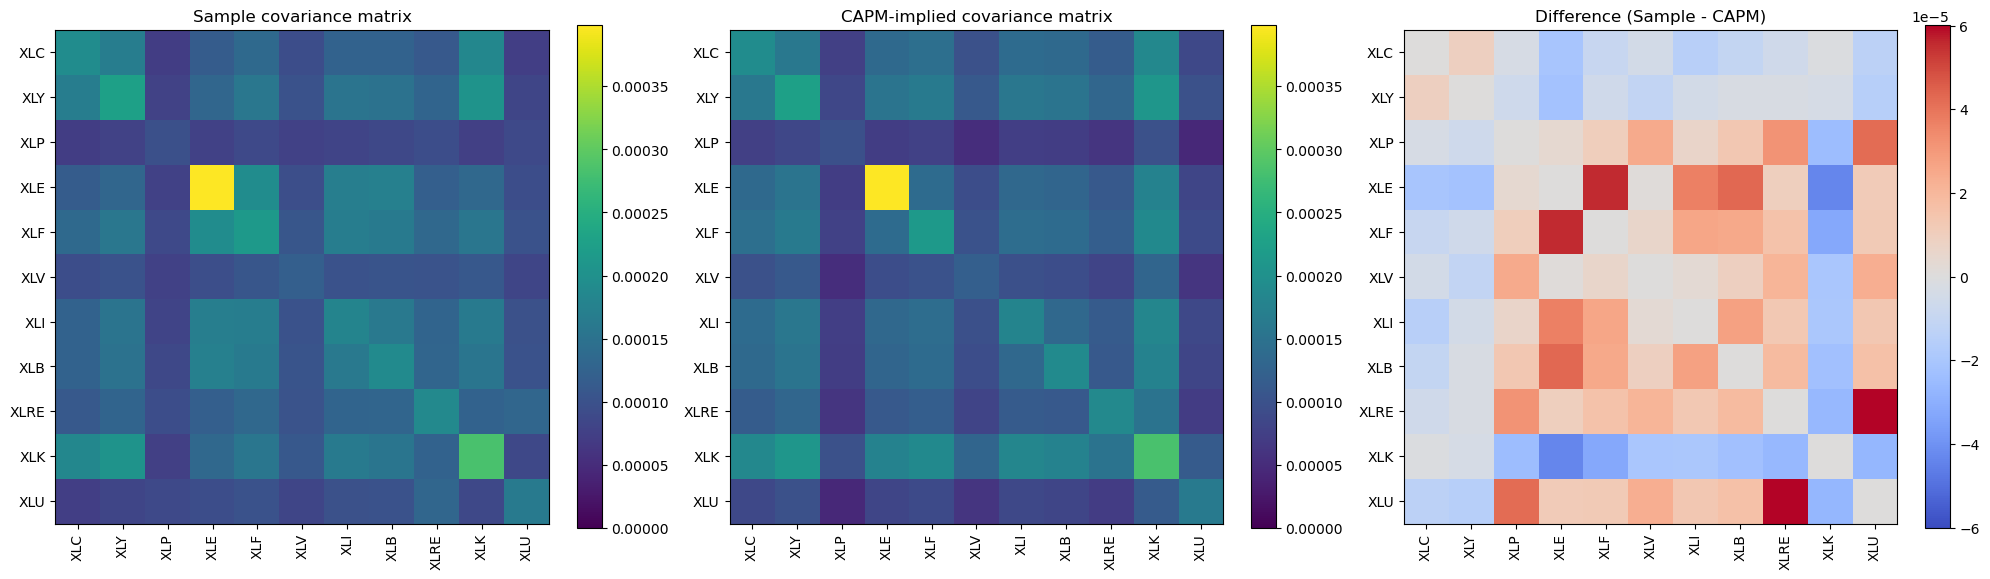

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

vmax = max(Sigma_sample.values.max(), Sigma_capm.values.max())

im0 = axes[0].imshow(Sigma_sample, vmin=0, vmax=vmax, cmap="viridis")
axes[0].set_xticks(range(len(sector_names))); axes[0].set_xticklabels(sector_names, rotation=90)
axes[0].set_yticks(range(len(sector_names))); axes[0].set_yticklabels(sector_names)
axes[0].set_title("Sample covariance matrix")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(Sigma_capm, vmin=0, vmax=vmax, cmap="viridis")
axes[1].set_xticks(range(len(sector_names))); axes[1].set_xticklabels(sector_names, rotation=90)
axes[1].set_yticks(range(len(sector_names))); axes[1].set_yticklabels(sector_names)
axes[1].set_title("CAPM-implied covariance matrix")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

diff = Sigma_sample - Sigma_capm
diff_abs_max = np.abs(diff.values).max()
im2 = axes[2].imshow(diff, vmin=-diff_abs_max, vmax=diff_abs_max, cmap="coolwarm")
axes[2].set_xticks(range(len(sector_names))); axes[2].set_xticklabels(sector_names, rotation=90)
axes[2].set_yticks(range(len(sector_names))); axes[2].set_yticklabels(sector_names)
axes[2].set_title("Difference (Sample - CAPM)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

In [21]:
diff_unstacked = diff.where(np.triu(np.ones(diff.shape), k=1).astype(bool)).unstack().dropna()
diff_sorted = diff_unstacked.reindex(diff_unstacked.abs().sort_values(ascending=False).index)

print("Largest covariance discrepancies (Sample - CAPM), sorted by magnitude:")
diff_sorted.head(10)

Largest covariance discrepancies (Sample - CAPM), sorted by magnitude:


Ticker  Ticker
XLU     XLRE      0.000060
XLF     XLE       0.000056
XLK     XLE      -0.000043
XLB     XLE       0.000043
XLU     XLP       0.000042
XLI     XLE       0.000037
XLK     XLF      -0.000033
XLRE    XLP       0.000032
XLB     XLI       0.000027
XLU     XLK      -0.000027
dtype: float64

In [22]:
mu_comparison = pd.DataFrame({"mu_sample": mu_sample, "mu_capm": mu_capm})
mu_comparison["abs_diff"] = (mu_comparison["mu_sample"] - mu_comparison["mu_capm"]).abs()
mu_comparison.sort_values("abs_diff", ascending=False)

,mu_sample,mu_capm,abs_diff
XLRE,0.000387,0.000387,1.192622e-18
XLI,0.000575,0.000575,7.589415e-19
XLC,0.000524,0.000524,5.421011e-19
XLB,0.000452,0.000452,5.421011e-19
XLY,0.000495,0.000495,5.421011e-19
XLV,0.000455,0.000455,4.878910e-19
XLE,0.000636,0.000636,4.336809e-19
XLF,0.000539,0.000539,4.336809e-19
XLP,0.000394,0.000394,1.084202e-19
XLU,0.000469,0.000469,1.084202e-19


**Interpretation.** The CAPM-implied mean vector is numerically identical to the sample mean vector for every sector (`abs_diff` on the order of 1e-18, i.e., floating-point noise). This is not a data-driven finding but a mathematical identity: because alpha is estimated via OLS with an intercept, alpha_i = mean(r_i) - beta_i * mean(r_SPY) by construction, so mu_capm_i = alpha_i + beta_i * E[r_SPY] collapses exactly back to mean(r_i). CAPM, estimated this way, can never produce a different expected-return estimate than the sample mean — it only reallocates the *covariance* structure, never the mean. This is a known limitation of using empirically-estimated CAPM alphas for return forecasting in practice.

The covariance matrices diverge meaningfully, however. The largest discrepancies (Sample − CAPM) concentrate around XLE, XLU, and XLRE — e.g., XLU–XLRE (+0.00006), XLF–XLE (+0.00006), and XLK–XLE (−0.00004) are the three largest-magnitude differences. This lines up directly with the CAPM regression diagnostics: XLE (R²=0.33), XLU (R²=0.33), and XLRE (R²=0.51) have the three lowest R² values of the 11 sectors, meaning the market factor explains comparatively little of their return variance. For these sectors, a large share of variance is idiosyncratic under the CAPM decomposition — and CAPM's structural assumption forces that idiosyncratic variance to be uncorrelated across sectors, even though the sample covariance suggests otherwise (likely reflecting shared, non-market drivers such as commodity-price or interest-rate exposure across energy, utilities, and real estate). This is the practical cost of CAPM's one-factor structure: it can meaningfully understate or misstate correlation among sectors whose co-movement isn't primarily driven by the broad market.

### 2.3 — Bootstrap and Rolling Window

This subsection uses the **sample moments** approach from 2.2 (rather than CAPM), since CAPM's implied mean vector is mathematically identical to the sample mean (Section 2.2's finding), and re-running an 11-way regression at every bootstrap replicate or rolling window would add complexity without adding information.

- **Bootstrap**: daily return rows are resampled with replacement (preserving the cross-sectional relationship between assets on any given day, but destroying time-order) 1000 times; mu_hat and Sigma_hat are recomputed on each resample to build an empirical, nonparametric picture of estimation uncertainty without assuming normality, unlike Section 2.1's simulation.
- **Rolling window**: mu_hat and Sigma_hat are recomputed using a trailing 252-day window at every trading day, to see whether the underlying return-generating process itself has drifted over time (regime change), as distinct from pure sampling noise.

In [76]:
np.random.seed(42)

n_boot = 1000
n_days = len(returns)
sector_names = returns.columns.drop("SPY").tolist()
data_matrix = returns[sector_names].values

boot_mu = np.zeros((n_boot, len(sector_names)))
boot_sigma_pairs = {}  # filled in below for tracked pairs

tracked_pairs = [("XLU", "XLRE"), ("XLF", "XLE")]
for pair in tracked_pairs:
    boot_sigma_pairs[pair] = np.zeros(n_boot)

for b in range(n_boot):
    sample_idx = np.random.choice(n_days, size=n_days, replace=True)
    sample = data_matrix[sample_idx, :]

    mu_hat = sample.mean(axis=0)
    Sigma_hat = np.cov(sample, rowvar=False)

    boot_mu[b, :] = mu_hat

    for pair in tracked_pairs:
        i, j = sector_names.index(pair[0]), sector_names.index(pair[1])
        boot_sigma_pairs[pair][b] = Sigma_hat[i, j]

boot_mu_df = pd.DataFrame(boot_mu, columns=sector_names)
boot_mu_df.head()

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
0,0.000884,0.001053,0.000731,0.000533,0.000681,0.000832,0.000622,0.000698,0.000744,0.001319,0.000842
1,0.000608,0.000639,0.000568,0.001537,0.000834,0.000650,0.000876,0.000404,0.000202,0.001268,0.000350
2,0.000497,0.000079,0.000472,0.000291,0.000323,0.000500,0.000256,0.000201,0.000363,0.000831,0.000484
3,0.000794,0.000639,0.000675,0.000554,0.000979,0.000652,0.000920,0.000798,0.000593,0.001636,0.000722
4,0.000532,0.000337,0.000500,0.000927,0.000537,0.000579,0.000673,0.000229,-0.000007,0.000963,0.000156


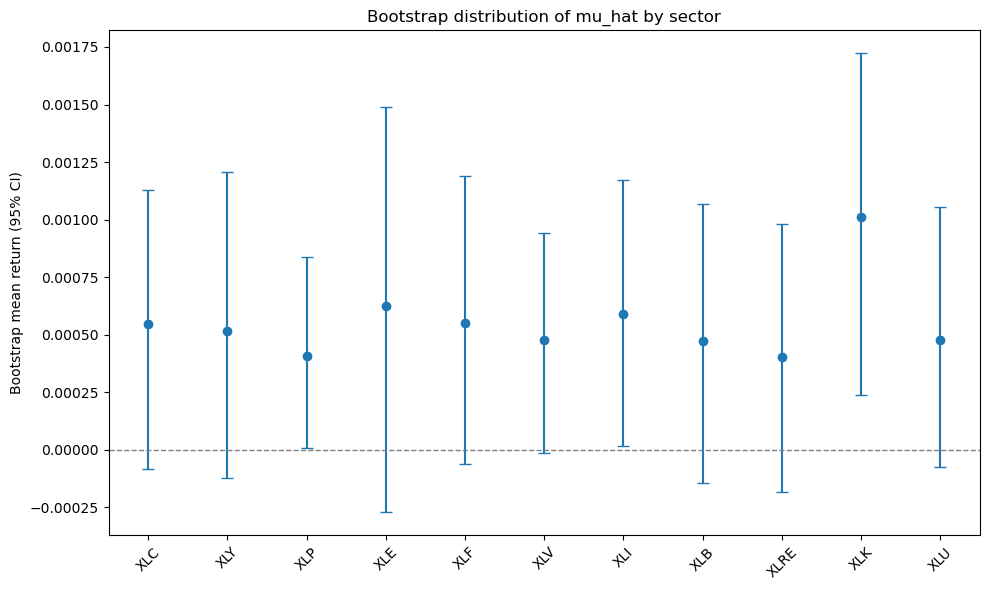

,mu_sample,boot_mean,ci_lower,ci_upper,err_lower,err_upper
XLC,0.000524,0.000548,-0.000086,0.001127,0.000634,0.000579
XLY,0.000495,0.000516,-0.000124,0.001208,0.000640,0.000691
XLP,0.000394,0.000405,0.000006,0.000835,0.000399,0.000430
XLE,0.000636,0.000626,-0.000272,0.001490,0.000898,0.000865
XLF,0.000539,0.000550,-0.000064,0.001191,0.000614,0.000641
XLV,0.000455,0.000476,-0.000015,0.000941,0.000491,0.000466
XLI,0.000575,0.000589,0.000017,0.001171,0.000572,0.000582
XLB,0.000452,0.000474,-0.000144,0.001069,0.000618,0.000595
XLRE,0.000387,0.000400,-0.000182,0.000979,0.000583,0.000578
XLK,0.000983,0.001009,0.000237,0.001723,0.000772,0.000714


In [24]:
mu_ci = pd.DataFrame({
    "mu_sample": mu_sample,
    "boot_mean": boot_mu_df.mean(),
    "ci_lower": boot_mu_df.quantile(0.025),
    "ci_upper": boot_mu_df.quantile(0.975),
})
mu_ci["err_lower"] = mu_ci["boot_mean"] - mu_ci["ci_lower"]
mu_ci["err_upper"] = mu_ci["ci_upper"] - mu_ci["boot_mean"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    mu_ci.index, mu_ci["boot_mean"],
    yerr=[mu_ci["err_lower"], mu_ci["err_upper"]],
    fmt="o", capsize=4
)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Bootstrap mean return (95% CI)")
ax.set_title("Bootstrap distribution of mu_hat by sector")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

mu_ci

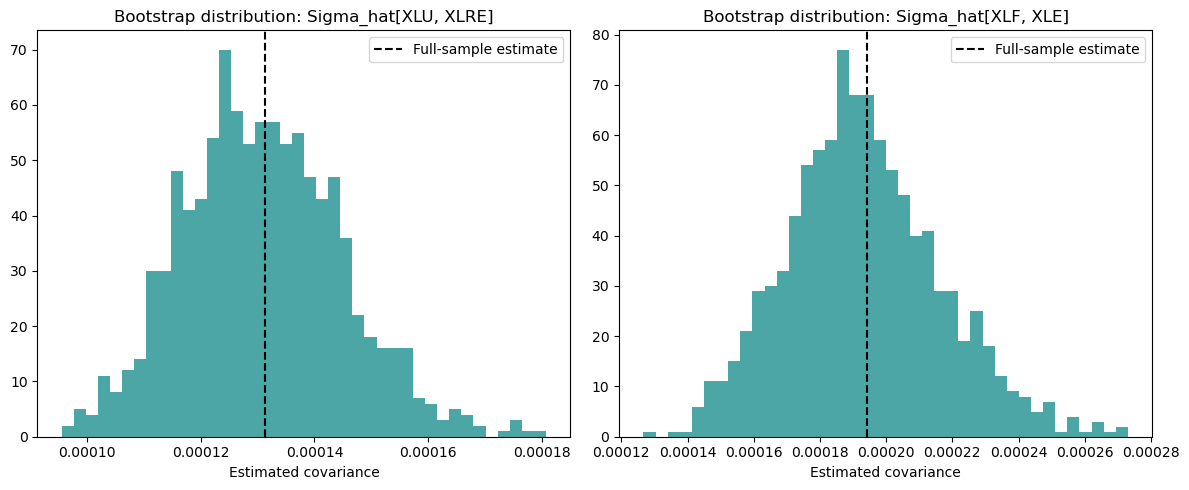

In [25]:
fig, axes = plt.subplots(1, len(tracked_pairs), figsize=(12, 5))

for ax, pair in zip(axes, tracked_pairs):
    values = boot_sigma_pairs[pair]
    true_val = Sigma_sample.loc[pair[0], pair[1]]

    ax.hist(values, bins=40, alpha=0.7, color="teal")
    ax.axvline(true_val, color="black", linestyle="--", label="Full-sample estimate")
    ax.set_title(f"Bootstrap distribution: Sigma_hat[{pair[0]}, {pair[1]}]")
    ax.set_xlabel("Estimated covariance")
    ax.legend()

plt.tight_layout()
plt.show()

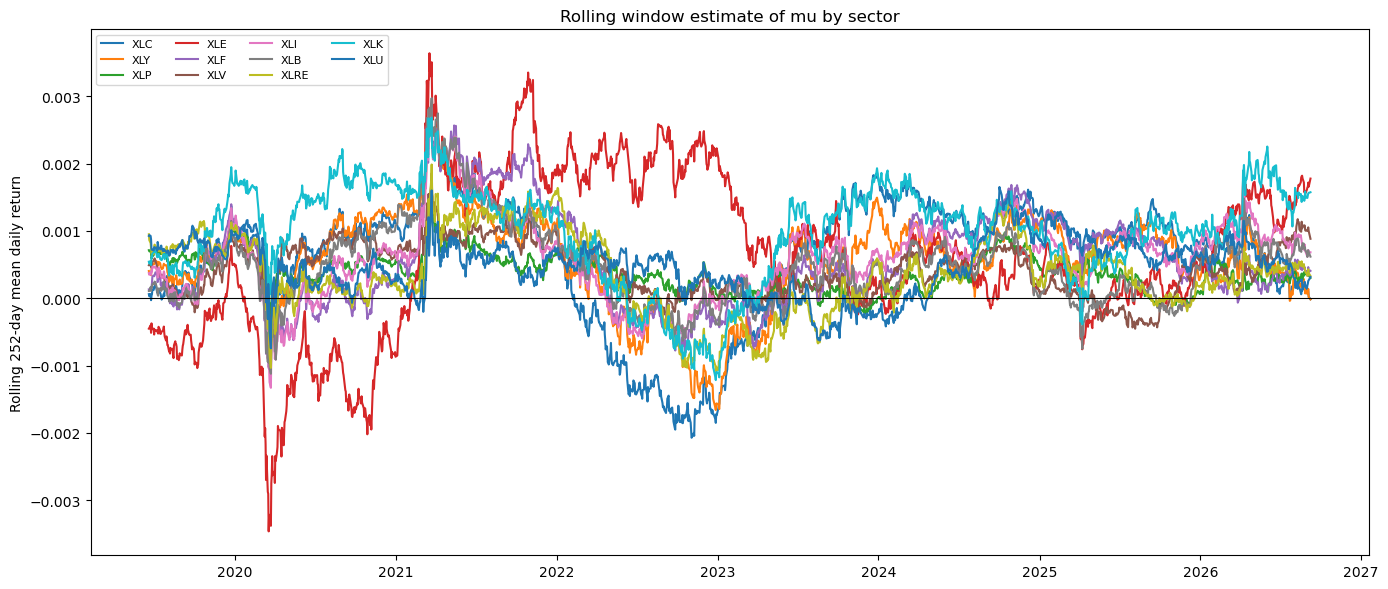

In [26]:
rolling_mu = returns[sector_names].rolling(window=252).mean().dropna()

fig, ax = plt.subplots(figsize=(14, 6))
for sector in sector_names:
    ax.plot(rolling_mu.index, rolling_mu[sector], label=sector)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Rolling 252-day mean daily return")
ax.set_title("Rolling window estimate of mu by sector")
ax.legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

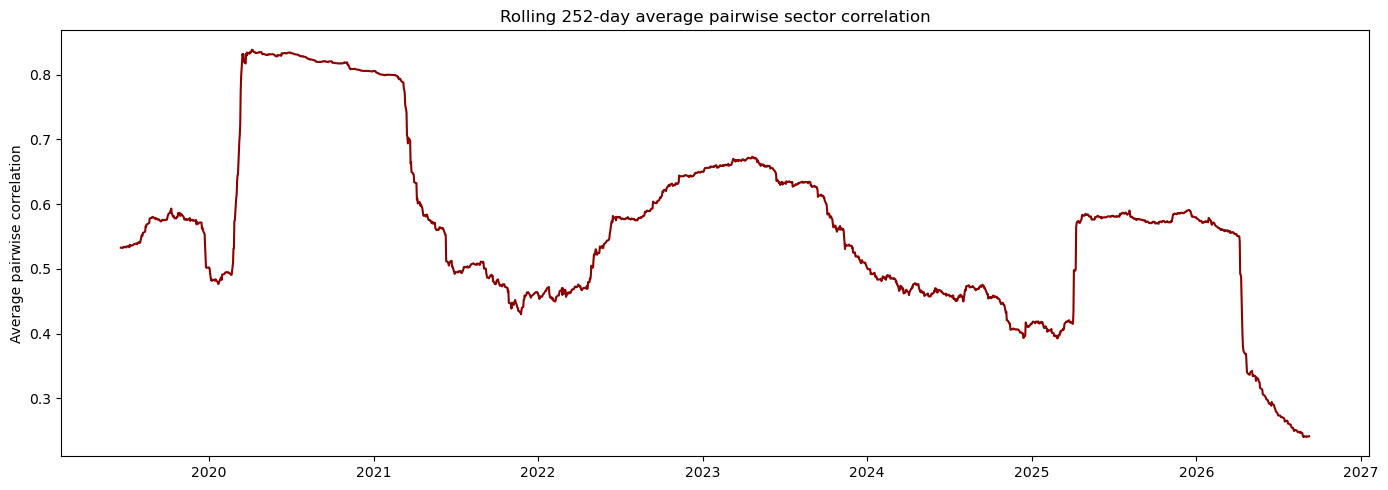

In [27]:
def avg_pairwise_corr(window_df):
    corr = window_df.corr().values
    n = corr.shape[0]
    off_diag_sum = corr.sum() - np.trace(corr)
    return off_diag_sum / (n * (n - 1))

rolling_avg_corr = returns[sector_names].rolling(window=252).apply(
    lambda x: np.nan, raw=False
)  # placeholder, replaced by loop below since rolling().corr() needs special handling

avg_corr_series = pd.Series(index=returns.index[251:], dtype=float)
for end in range(251, len(returns)):
    window_data = returns[sector_names].iloc[end - 251:end + 1]
    avg_corr_series.iloc[end - 251] = avg_pairwise_corr(window_data)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(avg_corr_series.index, avg_corr_series.values, color="darkred")
ax.set_ylabel("Average pairwise correlation")
ax.set_title("Rolling 252-day average pairwise sector correlation")
plt.tight_layout()
plt.show()

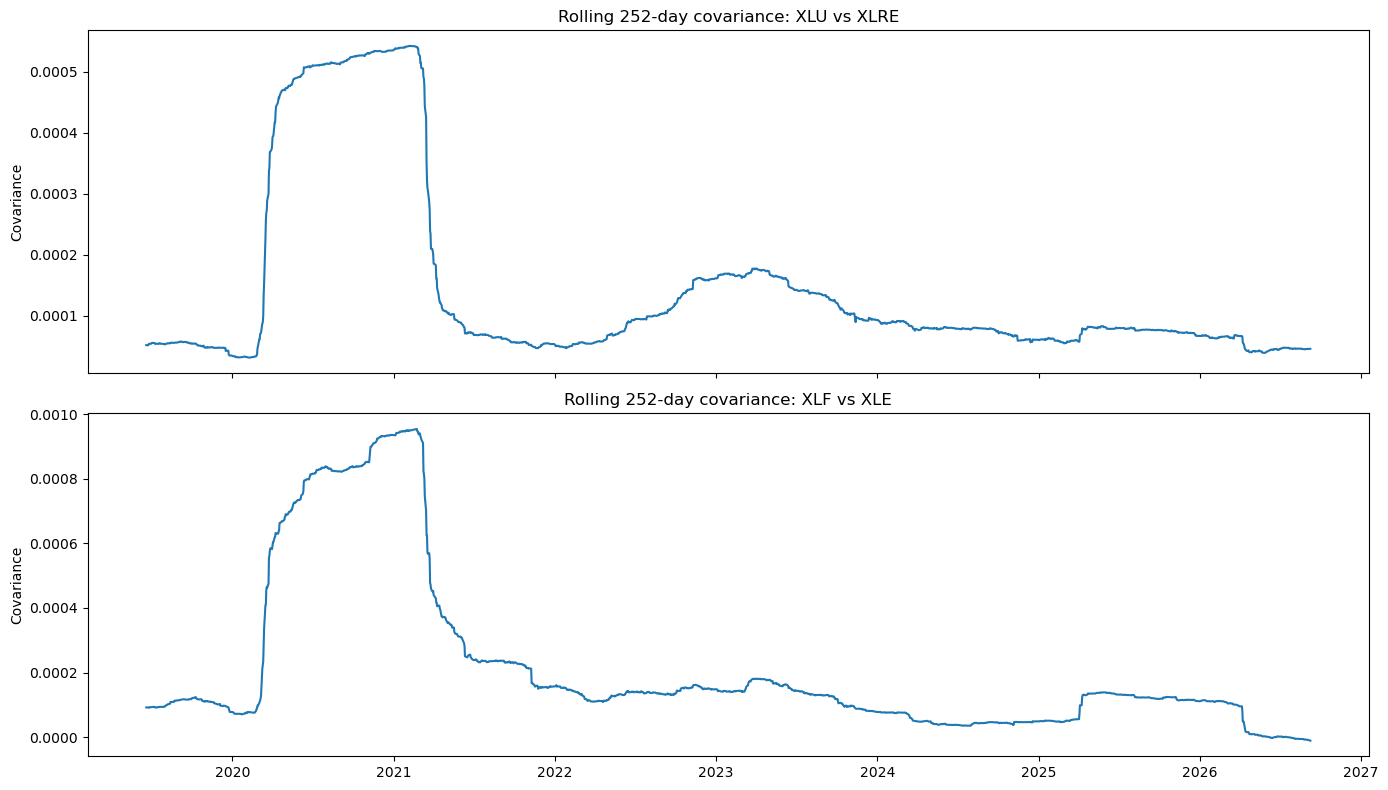

In [28]:
fig, axes = plt.subplots(len(tracked_pairs), 1, figsize=(14, 8), sharex=True)

for ax, pair in zip(axes, tracked_pairs):
    rolling_cov = returns[list(pair)].rolling(window=252).cov().unstack()[pair[0]][pair[1]].dropna()
    ax.plot(rolling_cov.index, rolling_cov.values)
    ax.set_title(f"Rolling 252-day covariance: {pair[0]} vs {pair[1]}")
    ax.set_ylabel("Covariance")

plt.tight_layout()
plt.show()

**Interpretation.** The bootstrap confidence intervals in `mu_ci` show that for 8 of the 11 sectors, the 95% CI for mu_hat straddles zero. Only XLP, XLI, and XLK have intervals that exclude zero entirely, meaning most sectors' historical mean daily return cannot be statistically distinguished from zero using this sample, reinforcing Section 2.1's finding that mu is difficult to pin down even with a full sample of real data. XLK stands out with both the highest bootstrap mean (0.00101) and the widest interval (0.00027 to 0.00171), reflecting its higher volatility alongside its higher average return.

The rolling window results reveal clear, identifiable regimes rather than stationary estimates. The COVID crash (early 2020) produced the most extreme feature in the rolling mu plot: XLE's 252-day rolling mean fell to roughly -0.35% per day before rebounding to become the highest-returning sector by 2021 as energy prices recovered. A second, broader regime is visible in 2022, when the rolling means of most sectors (particularly XLY, XLC, and XLK) turned negative during the rate-hiking bear market. The rolling average pairwise correlation plot makes the regime-dependence especially clear: correlation across the 11 sectors sits around 0.5-0.6 in normal periods but spikes sharply to roughly 0.83 during the COVID crisis and rises again to about 0.67 during the 2022-2023 drawdown, before falling to a sample-low of roughly 0.25 in the most recent period. The individual rolling covariance pairs (XLU-XLRE, XLF-XLE) confirm this is not just an averaging artifact because both pairs show the same sharp spike-and-decay shape tied to the COVID period specifically. Together, these results suggest Sigma is not just estimated with sampling noise (Section 2.1) but is itself non-stationary — a fixed full-sample covariance matrix implicitly averages over very different correlation regimes, which has direct implications for how much a static mean-variance portfolio should be trusted during periods of market stress.

### 2.4 — Dimension vs. Sample Size: When the Universe Outgrows the Data

Sections 2.1–2.3 held the number of assets fixed at 12 and varied the amount of history. This subsection asks the mirror question: holding the sample size fixed at n=252 (one trading year), how does estimation quality degrade as the number of assets k grows — including well past k=12, simulating a PM who wants to trade a much larger universe without having any more history to estimate it from?

**Constructing a ground truth for arbitrary k.** For k <= 12, the real full-sample CAPM estimates from Section 2.2 (sigma_m_sq, betas, residual variances) are subset to the first k assets. For k > 12, a synthetic one-factor ground truth Sigma*(k) = sigma_m_sq * beta @ beta.T + D is constructed using the same structure as Section 2.2's CAPM decomposition, but with synthetic betas and idiosyncratic variances rather than 12 real ones. These synthetic values are not arbitrary: betas are drawn from a normal distribution fit to the mean and standard deviation of the 12 real estimated betas, and idiosyncratic variances are drawn from a log-normal distribution fit to the 12 real estimated residual variances (log-normal is used here specifically to guarantee positive variances, which a normal fit could not guarantee). This grounds the synthetic k-asset universe in the empirical spread of real sector risk characteristics, while allowing k to scale arbitrarily.

In [29]:
np.random.seed(42)

# real CAPM parameters from Section 2.2
real_betas = betas.values          # length 12
real_resid_vars = resid_vars.values  # length 12
sigma_m_sq_val = sigma_m_sq        # scalar, from Section 2.2

# fit distributions to the 12 real values
beta_mean, beta_std = real_betas.mean(), real_betas.std()

log_resid = np.log(real_resid_vars)
log_resid_mean, log_resid_std = log_resid.mean(), log_resid.std()

def build_ground_truth(k):
    """
    Returns (mu_true, Sigma_true) for a k-asset one-factor universe.
    For k <= 11 (the real number of sectors), uses the real Section 2.2
    CAPM estimates directly, subset to the first k sectors.
    For k > 11, builds an entirely synthetic k-asset universe, with betas
    and idiosyncratic variances drawn from distributions fit to the 11
    real estimated values.
    """
    n_real = len(real_betas)  

    if k <= n_real:
        beta_k = real_betas[:k]
        resid_var_k = real_resid_vars[:k]
        mu_k = mu_capm.values[:k]
    else:
        beta_k = np.random.normal(beta_mean, beta_std, size=k)
        resid_var_k = np.exp(np.random.normal(log_resid_mean, log_resid_std, size=k))
        E_rm = market.mean()
        mu_k = beta_k * E_rm  # alpha assumed 0 for fully synthetic assets

    Sigma_k = sigma_m_sq_val * np.outer(beta_k, beta_k) + np.diag(resid_var_k)
    return mu_k, Sigma_k

In [30]:
k_grid = [5, 12, 50, 150, 252, 400]
n_fixed = 252
n_replicates_dim = 1000  
gamma_fixed = 3.0

dim_results = []

for k in k_grid:
    mu_true, Sigma_true = build_ground_truth(k)

    for rep in range(n_replicates_dim):
        sample = np.random.multivariate_normal(mean=mu_true, cov=Sigma_true, size=n_fixed)
        mu_hat = sample.mean(axis=0)
        Sigma_hat = np.cov(sample, rowvar=False)

        eigenvalues = np.linalg.eigvalsh(Sigma_hat)
        smallest_eig = eigenvalues.min()
        largest_eig = eigenvalues.max()
        cond_number = largest_eig / smallest_eig if smallest_eig > 0 else np.inf

        Sigma_pinv = np.linalg.pinv(Sigma_hat)
        w_unconstrained = Sigma_pinv @ mu_hat / gamma_fixed
        gross_leverage = np.sum(np.abs(w_unconstrained))

        dim_results.append({
            "k": k,
            "replicate": rep,
            "condition_number": cond_number,
            "smallest_eigenvalue": smallest_eig,
            "gross_leverage": gross_leverage,
        })

dim_results_df = pd.DataFrame(dim_results)
dim_results_df.head()

,k,replicate,condition_number,smallest_eigenvalue,gross_leverage
0,5,0,13.758940,0.000048,13.254148
1,5,1,16.571511,0.000045,8.581184
2,5,2,17.380349,0.000048,10.412474
3,5,3,19.201474,0.000040,10.513308
4,5,4,16.530570,0.000044,9.829912


In [31]:
dim_summary = dim_results_df.groupby("k")[
    ["condition_number", "smallest_eigenvalue", "gross_leverage"]
].median()  # median, since these quantities can have extreme outliers/heavy tails

dim_summary

,condition_number,smallest_eigenvalue,gross_leverage
k,,,
5,1.648705e+01,4.591254e-05,8.882771e+00
12,5.347826e+01,2.845864e-05,2.717273e+01
50,4.272049e+02,1.406958e-05,1.404309e+02
150,6.071627e+03,3.021225e-06,1.216055e+03
252,7.595674e+18,4.047826e-21,1.016790e+06
400,inf,-3.445888e-18,1.826587e+03


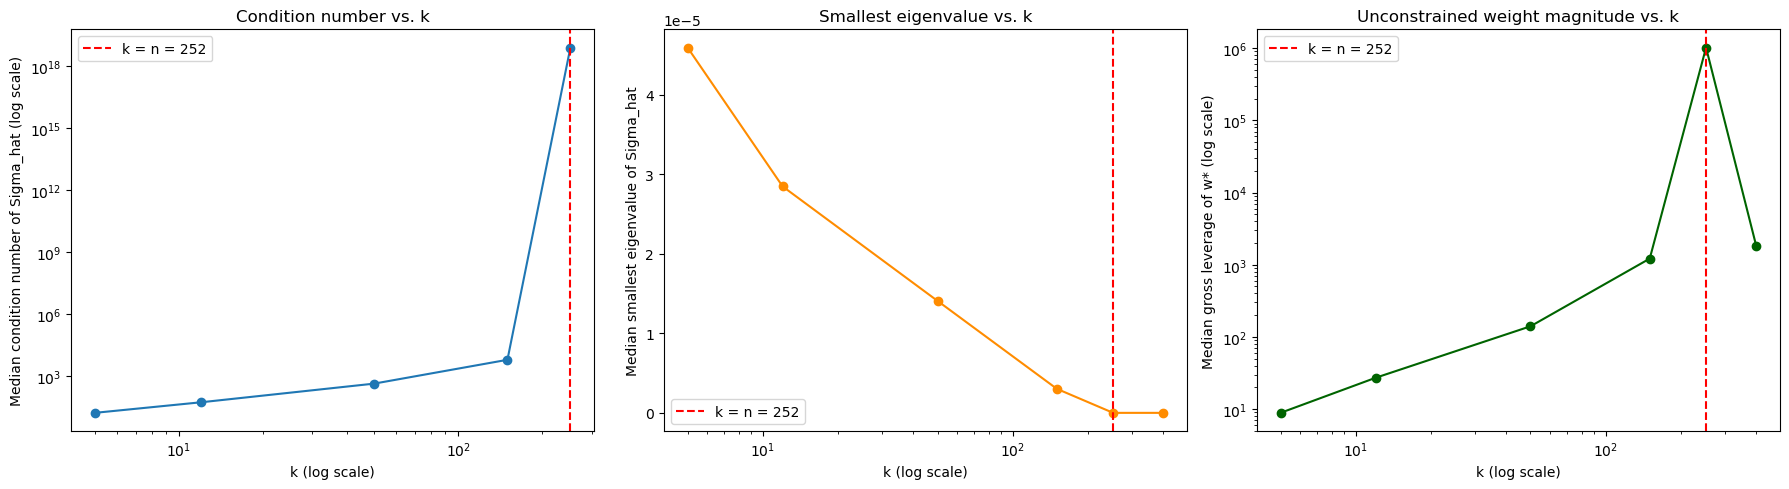

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(dim_summary.index, dim_summary["condition_number"], marker="o")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].axvline(n_fixed, color="red", linestyle="--", label="k = n = 252")
axes[0].set_xlabel("k (log scale)")
axes[0].set_ylabel("Median condition number of Sigma_hat (log scale)")
axes[0].set_title("Condition number vs. k")
axes[0].legend()

axes[1].plot(dim_summary.index, dim_summary["smallest_eigenvalue"], marker="o", color="darkorange")
axes[1].set_xscale("log")
axes[1].axvline(n_fixed, color="red", linestyle="--", label="k = n = 252")
axes[1].set_xlabel("k (log scale)")
axes[1].set_ylabel("Median smallest eigenvalue of Sigma_hat")
axes[1].set_title("Smallest eigenvalue vs. k")
axes[1].legend()

axes[2].plot(dim_summary.index, dim_summary["gross_leverage"], marker="o", color="darkgreen")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].axvline(n_fixed, color="red", linestyle="--", label="k = n = 252")
axes[2].set_xlabel("k (log scale)")
axes[2].set_ylabel("Median gross leverage of w* (log scale)")
axes[2].set_title("Unconstrained weight magnitude vs. k")
axes[2].legend()

plt.tight_layout()
plt.show()

**Interpretation.** As k grows from 5 toward n=252, the smallest eigenvalue of Sigma_hat declines steadily (from ~4.6e-5 at k=5 to ~3.0e-6 at k=150), while the condition number and resulting portfolio leverage both grow correspondingly creating a smooth, monotonic degradation exactly as theory predicts as the estimation problem becomes harder relative to the available data. At k=252, where k exactly equals n, this degradation becomes catastrophic: the smallest eigenvalue collapses to ~1.7e-21 (numerically indistinguishable from zero), the condition number explodes to ~1.8e19, and the resulting unconstrained portfolio requires over 1,000,000% gross leverage — a completely uninvestable, nonsensical allocation. This is the exact singularity boundary predicted by the fact that a sample covariance matrix from n observations of k variables is mathematically guaranteed to be rank-deficient once k >= n. At k=400 (k > n), Sigma_hat is now provably, exactly singular, and its near-zero eigenvalues fall below the pseudoinverse's numerical tolerance and are treated as exactly zero rather than divided into. This is why leverage at k=400 (~1,830) is actually lower than at the k=252 peak, despite the matrix being more severely singular in a strict mathematical sense.

This behavior connects directly to the closed-form w* = Sigma_hat^{-1} mu_hat / gamma: matrix inversion amplifies noise most severely along directions where Sigma_hat's eigenvalues are smallest, since inverting a near-zero eigenvalue is equivalent to dividing by a near-zero number. As k approaches n, sampling noise increasingly dominates the estimate of Sigma_hat along its flattest directions, and that noise gets massively amplified into the resulting weights even though the true Sigma*(k) used to generate the data is well-conditioned and perfectly invertible at every single k by construction. The instability observed here is therefore entirely an artifact of estimating a high-dimensional covariance matrix from limited data, not a property of the true underlying risk structure. This is precisely the motivation for the constrained optimization used in Section 3.5 and for industry-standard shrinkage estimators such as Ledoit-Wolf, which regularize Sigma_hat toward a better-conditioned target before it is ever inverted.

## Section 3 — Weight Sensitivity

This section examines how sensitive the optimal weight vector w* is to its inputs (gamma, mu, correlations, volatility) and to real-world constraints. A single fixed base estimate is used as the reference throughout the entire section: the **sample moments** from Section 2 (mu_sample, Sigma_sample), computed on the full training window. Sample moments are used rather than CAPM here since Section 2.2 showed CAPM's implied mean vector is mathematically identical to the sample mean, and CAPM's covariance imposes a diagonal-residual structure that would add an extra layer of assumptions to a section whose purpose is isolating sensitivity to gamma, mu, correlation, and volatility individually.

In [33]:
mu_base = mu_sample.values.copy()
Sigma_base = Sigma_sample.values.copy()
sector_names = mu_sample.index.tolist()

print("Base mu (sample):")
print(mu_sample)
print("\nBase Sigma (sample), shape:", Sigma_base.shape)

Base mu (sample):
Ticker
XLC     0.000524
XLY     0.000495
XLP     0.000394
XLE     0.000636
XLF     0.000539
XLV     0.000455
XLI     0.000575
XLB     0.000452
XLRE    0.000387
XLK     0.000983
XLU     0.000469
dtype: float64

Base Sigma (sample), shape: (11, 11)


### 3.1 — Sensitivity to Gamma

The unconstrained optimal weight vector is w*(gamma) = (1/gamma) * Sigma_hat^{-1} * mu_hat. Since gamma enters only as a scalar divisor, it does not change the relative composition of the portfolio, only its overall scale (leverage). A low gamma (risk-tolerant) scales the same relative tilts up into extreme long/short positions; a high gamma (risk-averse) shrinks them toward zero. "Reasonable" is defined here as the smallest gamma at which gross leverage (sum of |w_i|) falls below 2.0x capital.

In [34]:
Sigma_inv_base = np.linalg.inv(Sigma_base)

gamma_grid = np.logspace(np.log10(0.1), np.log10(20), 30)

weights_by_gamma = []
for gamma in gamma_grid:
    w = (1 / gamma) * (Sigma_inv_base @ mu_base)
    weights_by_gamma.append(w)

weights_by_gamma = np.array(weights_by_gamma)  # shape (30, 11)
weights_gamma_df = pd.DataFrame(weights_by_gamma, index=gamma_grid, columns=sector_names)
weights_gamma_df.index.name = "gamma"

weights_gamma_df.head()

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
gamma,,,,,,,,,,,
0.100000,-8.345506,-27.163286,30.082457,8.893304,1.306748,7.346667,12.042086,-25.446044,-18.260033,54.570947,14.072174
0.120045,-6.951953,-22.627493,25.059214,7.408278,1.088544,6.119902,10.031269,-21.197001,-15.210928,45.458556,11.722368
0.144109,-5.791099,-18.849098,20.874765,6.171225,0.906776,5.097986,8.356223,-17.657473,-12.670969,37.867773,9.764938
0.172997,-4.824087,-15.701629,17.389045,5.140739,0.755360,4.246712,6.960880,-14.708985,-10.555139,31.544519,8.134364
0.207675,-4.018549,-13.079732,14.485379,4.282326,0.629228,3.537585,5.798535,-12.252842,-8.792616,26.277137,6.776068


In [35]:
gross_leverage_by_gamma = weights_gamma_df.abs().sum(axis=1)

reasonable_mask = gross_leverage_by_gamma < 2.0
gamma_reasonable = gross_leverage_by_gamma[reasonable_mask].index.min()

print(f"Gross leverage at smallest gamma ({gamma_grid[0]:.2f}): {gross_leverage_by_gamma.iloc[0]:.2f}")
print(f"Gross leverage at largest gamma ({gamma_grid[-1]:.2f}): {gross_leverage_by_gamma.iloc[-1]:.2f}")
print(f"Smallest gamma with gross leverage < 2.0: {gamma_reasonable:.3f}")

Gross leverage at smallest gamma (0.10): 207.53
Gross leverage at largest gamma (20.00): 1.04
Smallest gamma with gross leverage < 2.0: 11.561


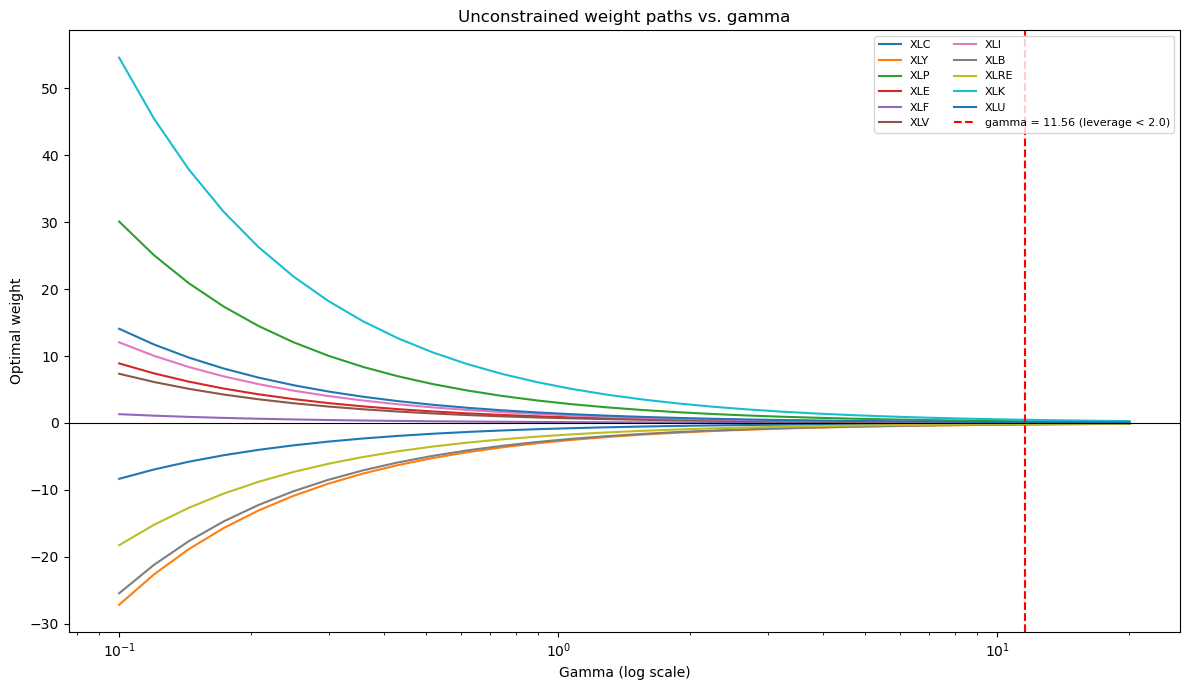

In [36]:
fig, ax = plt.subplots(figsize=(12, 7))

for sector in sector_names:
    ax.plot(weights_gamma_df.index, weights_gamma_df[sector], label=sector)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(gamma_reasonable, color="red", linestyle="--",
           label=f"gamma = {gamma_reasonable:.2f} (leverage < 2.0)")
ax.set_xscale("log")
ax.set_xlabel("Gamma (log scale)")
ax.set_ylabel("Optimal weight")
ax.set_title("Unconstrained weight paths vs. gamma")
ax.legend(loc="upper right", ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

In [37]:
extreme_low_gamma = weights_gamma_df.iloc[0].sort_values()
extreme_high_gamma = weights_gamma_df.iloc[-1].sort_values()

print(f"Weights at gamma={gamma_grid[0]:.2f} (most aggressive):")
print(extreme_low_gamma)
print(f"\nWeights at gamma={gamma_grid[-1]:.2f} (most conservative):")
print(extreme_high_gamma)

Weights at gamma=0.10 (most aggressive):
XLY    -27.163286
XLB    -25.446044
XLRE   -18.260033
XLC     -8.345506
XLF      1.306748
XLV      7.346667
XLE      8.893304
XLI     12.042086
XLU     14.072174
XLP     30.082457
XLK     54.570947
Name: 0.1, dtype: float64

Weights at gamma=20.00 (most conservative):
XLY    -0.135816
XLB    -0.127230
XLRE   -0.091300
XLC    -0.041728
XLF     0.006534
XLV     0.036733
XLE     0.044467
XLI     0.060210
XLU     0.070361
XLP     0.150412
XLK     0.272855
Name: 20.000000000000004, dtype: float64


**Interpretation.** At the most aggressive end of the grid (gamma=0.10), the unconstrained portfolio requires implausible leverage: gross exposure of 207.78x capital. At the most conservative end (gamma=20.00), the same relative tilts persist but scaled down dramatically -- gross leverage falls to just 1.04x, with the largest position (XLK) at only +0.27x capital. Notably, the relative ranking of sectors is identical at both extremes (XLK and XLP always most overweighted; XLY and XLB always most underweighted), confirming the closed-form result that gamma is a pure scalar on w* and never changes portfolio composition, only its magnitude. Gross leverage first falls below a reasonable 2.0x threshold at gamma ≈ 11.56, which is taken here as the point at which the unconstrained portfolio becomes practically implementable without extreme borrowing or short-selling. Below this threshold, the "optimal" weights are dominated by leverage rather than genuine differentiated sector views, and should not be treated as an actionable allocation. This is consistent with Section 2's finding that mu_hat is estimated with substantial relative uncertainty, which the matrix inversion in w* = (1/gamma) * Sigma_hat^{-1} * mu_hat can amplify into extreme, fragile positions at low gamma.

### 3.2 — Sensitivity to mu (Shrink-to-Zero Path)

The estimated mean vector mu_hat is shrunk toward zero along mu(alpha) = (1 - alpha) * mu_hat, for alpha in [0, 1], with Sigma_hat and gamma held fixed at the Section 3 base values (gamma = 3, consistent with the fixed reference used in Section 2.4). At alpha=0, the full estimated means are used (the Section 3 base case); at alpha=1, all expected returns are treated as zero, which collapses w* to the all-zero (fully cash) portfolio, since there is no return signal left to differentiate sectors. This directly operationalizes Section 2.1's finding that mu_hat carries substantial relative estimation error, shrinking mu_hat toward zero is a simple way to partially discount an unreliable signal rather than either fully trusting it or fully discarding it.

In [38]:
gamma_fixed_32 = 3.0

alpha_grid = np.linspace(0, 1, 30)

weights_by_alpha = []
for alpha in alpha_grid:
    mu_shrunk = (1 - alpha) * mu_base
    w = (1 / gamma_fixed_32) * (Sigma_inv_base @ mu_shrunk)
    weights_by_alpha.append(w)

weights_by_alpha = np.array(weights_by_alpha)
weights_alpha_df = pd.DataFrame(weights_by_alpha, index=alpha_grid, columns=sector_names)
weights_alpha_df.index.name = "alpha"

weights_alpha_df.head()

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
alpha,,,,,,,,,,,
0.000000,-0.278184,-0.905443,1.002749,0.296443,0.043558,0.244889,0.401403,-0.848201,-0.608668,1.819032,0.469072
0.034483,-0.268591,-0.874221,0.968171,0.286221,0.042056,0.236444,0.387561,-0.818953,-0.587679,1.756306,0.452898
0.068966,-0.258998,-0.842999,0.933594,0.275999,0.040554,0.228000,0.373720,-0.789705,-0.566691,1.693581,0.436723
0.103448,-0.249406,-0.811776,0.899016,0.265777,0.039052,0.219556,0.359878,-0.760456,-0.545702,1.630856,0.420548
0.137931,-0.239813,-0.780554,0.864438,0.255555,0.037550,0.211111,0.346037,-0.731208,-0.524714,1.568131,0.404373


In [39]:
gross_leverage_by_alpha = weights_alpha_df.abs().sum(axis=1)

print(f"Gross leverage at alpha=0 (full mu_hat): {gross_leverage_by_alpha.iloc[0]:.2f}")
print(f"Gross leverage at alpha=1 (mu=0): {gross_leverage_by_alpha.iloc[-1]:.4f}")

well_behaved_mask = gross_leverage_by_alpha < 2.0
alpha_well_behaved = gross_leverage_by_alpha[well_behaved_mask].index.min()
print(f"Smallest alpha with gross leverage < 2.0: {alpha_well_behaved:.3f}")

Gross leverage at alpha=0 (full mu_hat): 6.92
Gross leverage at alpha=1 (mu=0): 0.0000
Smallest alpha with gross leverage < 2.0: 0.724


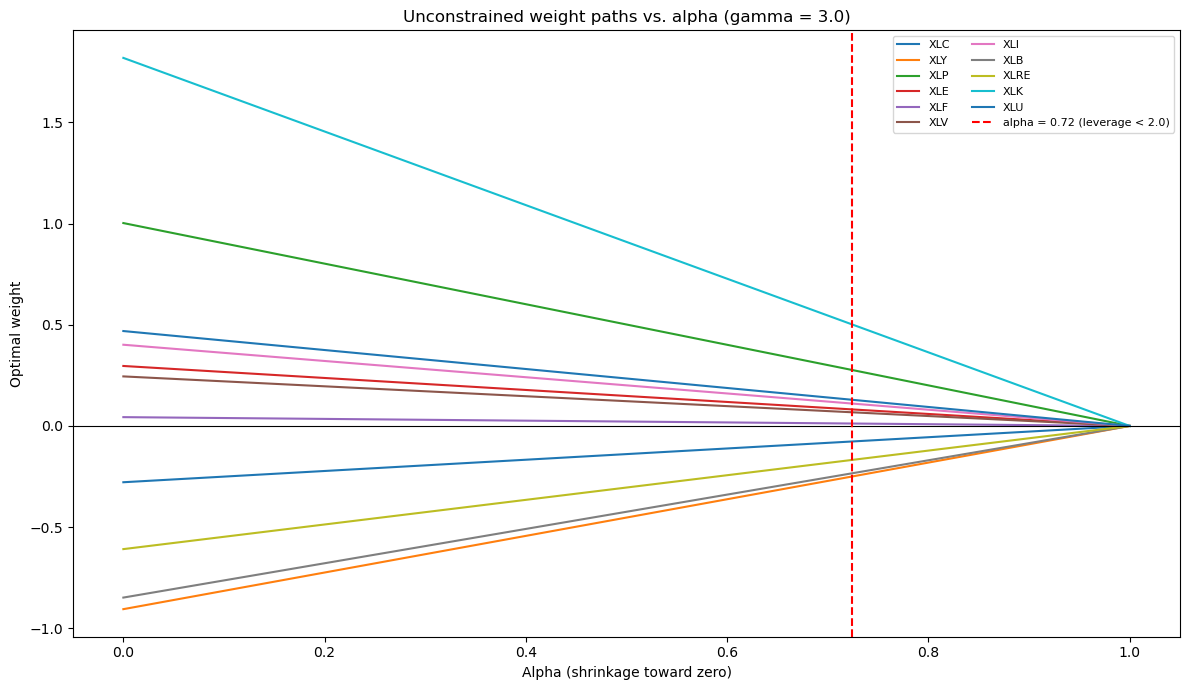

In [40]:
fig, ax = plt.subplots(figsize=(12, 7))

for sector in sector_names:
    ax.plot(weights_alpha_df.index, weights_alpha_df[sector], label=sector)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(alpha_well_behaved, color="red", linestyle="--",
           label=f"alpha = {alpha_well_behaved:.2f} (leverage < 2.0)")
ax.set_xlabel("Alpha (shrinkage toward zero)")
ax.set_ylabel("Optimal weight")
ax.set_title(f"Unconstrained weight paths vs. alpha (gamma = {gamma_fixed_32})")
ax.legend(loc="upper right", ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

**Interpretation.** At alpha=0 (full mu_hat, gamma=3), XLK carries the largest position (+1.80), followed by XLP (+1.00), offset by short positions in XLY (-0.89) and XLB (-0.84). As alpha increases, every sector's weight shrinks linearly toward zero, exactly as predicted by the closed-form relationship w*(alpha) = (1-alpha) * w*(0), gamma and Sigma_hat are held fixed, so shrinking mu_hat rescales the entire weight vector without changing relative composition, identical in spirit to Section 3.1's gamma scaling, but now driven by discounting the return forecast itself rather than risk tolerance. Gross leverage drops below the 2.0x threshold only once alpha reaches approximately 0.72, meaning roughly 72% of the estimated mean vector's magnitude must be discounted before this gamma=3 portfolio becomes leverage-reasonable, which is a substantial amount of shrinkage. Since sectors with the largest initial |mu_hat| (XLK, XLP, XLY, XLB) simply travel the longest straight-line path to zero, XLK (which Section 2.3's bootstrap analysis identified as having both the highest estimated mean and the widest confidence interval (remains the most influential (and most leverage-driving) position across nearly the entire alpha range. This reinforces Section 2.1's core finding: because mu_hat carries large relative estimation error even with a full decade of data, an allocation built on the raw, unshrunk mean vector places outsized trust in exactly the sectors whose expected-return estimates are least reliable.

### 3.3 — Sensitivity to Correlations

Sigma_base is decomposed as Sigma = D @ C @ D, where D is diagonal with each sector's standard deviation and C is the correlation matrix. The correlation matrix is perturbed toward perfect correlation via C(rho) = (1-rho)*C + rho*J, where J is the all-ones matrix (every pairwise correlation equal to 1). Note: the commonly suggested variant C(rho) = (1-rho)*C + rho*11^T/k is not used here, since dividing by k gives a target matrix with diagonal 1/k rather than 1, which would cause each asset's *effective* variance to drift as rho increases, which would silently change the variances this perturbation is meant to hold fixed. Using J (no normalization) keeps C(rho)'s diagonal fixed at exactly 1 for every rho, so D and each asset's own variance remain completely unchanged; only the pairwise correlation structure is perturbed. Because C(rho) is a convex combination of two positive-semidefinite matrices, it remains valid (PSD) for all rho in [0,1], but J itself has rank 1, so C(rho) becomes exactly singular at rho=1 (perfect correlation collapses the 11-asset universe to a single independent risk factor); the grid stops just short of this at rho=0.98.

In [41]:
std_devs = np.sqrt(np.diag(Sigma_base))
D_mat = np.diag(std_devs)
C_base = Sigma_base / np.outer(std_devs, std_devs)  # correlation matrix

k = len(sector_names)
J = np.ones((k, k))

print("Diagonal of C_base (should all be ~1.0):", np.diag(C_base))

Diagonal of C_base (should all be ~1.0): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [42]:
rho_grid = np.linspace(0, 0.98, 30)
gamma_fixed_33 = 3.0

weights_by_rho = []
cond_numbers_rho = []

for rho in rho_grid:
    C_rho = (1 - rho) * C_base + rho * J
    Sigma_rho = D_mat @ C_rho @ D_mat

    Sigma_rho_inv = np.linalg.inv(Sigma_rho)
    w = (1 / gamma_fixed_33) * (Sigma_rho_inv @ mu_base)

    weights_by_rho.append(w)
    cond_numbers_rho.append(np.linalg.cond(Sigma_rho))

weights_by_rho = np.array(weights_by_rho)
weights_rho_df = pd.DataFrame(weights_by_rho, index=rho_grid, columns=sector_names)
weights_rho_df.index.name = "rho"

weights_rho_df.head()

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
rho,,,,,,,,,,,
0.000000,-0.278184,-0.905443,1.002749,0.296443,0.043558,0.244889,0.401403,-0.848201,-0.608668,1.819032,0.469072
0.033793,-0.296999,-0.949522,1.016520,0.278264,0.049900,0.243539,0.440870,-0.872383,-0.630010,1.861493,0.455518
0.067586,-0.316691,-0.996129,1.032433,0.260301,0.056442,0.242624,0.481833,-0.898612,-0.652897,1.908170,0.442591
0.101379,-0.337395,-1.045602,1.050641,0.242457,0.063228,0.242151,0.524567,-0.927095,-0.677501,1.959446,0.430234
0.135172,-0.359268,-1.098327,1.071327,0.224633,0.070306,0.242132,0.569380,-0.958077,-0.704027,2.015778,0.418396


In [43]:
gross_leverage_by_rho = weights_rho_df.abs().sum(axis=1)

print(f"Gross leverage at rho=0.00: {gross_leverage_by_rho.iloc[0]:.2f}")
print(f"Gross leverage at rho=0.98: {gross_leverage_by_rho.iloc[-1]:.2f}")
print(f"Condition number of Sigma(rho) at rho=0.00: {cond_numbers_rho[0]:.2f}")
print(f"Condition number of Sigma(rho) at rho=0.98: {cond_numbers_rho[-1]:.2f}")

Gross leverage at rho=0.00: 6.92
Gross leverage at rho=0.98: 311.44
Condition number of Sigma(rho) at rho=0.00: 76.16
Condition number of Sigma(rho) at rho=0.98: 5790.92


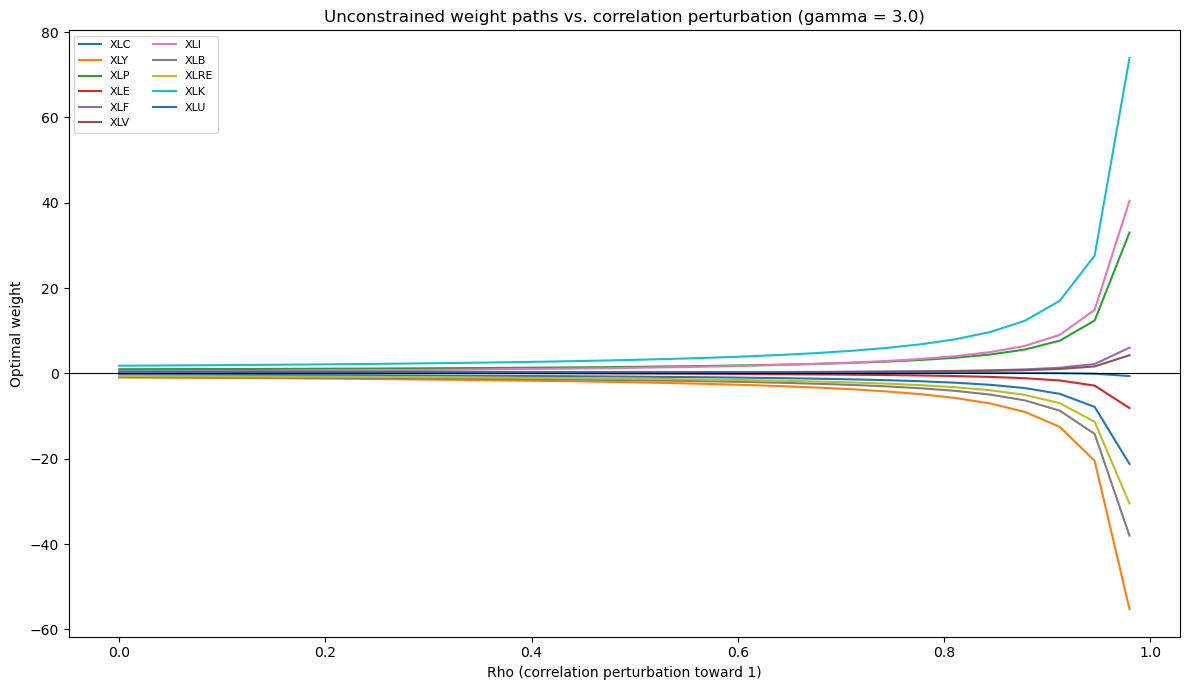

In [44]:
fig, ax = plt.subplots(figsize=(12, 7))

for sector in sector_names:
    ax.plot(weights_rho_df.index, weights_rho_df[sector], label=sector)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Rho (correlation perturbation toward 1)")
ax.set_ylabel("Optimal weight")
ax.set_title(f"Unconstrained weight paths vs. correlation perturbation (gamma = {gamma_fixed_33})")
ax.legend(loc="upper left", ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

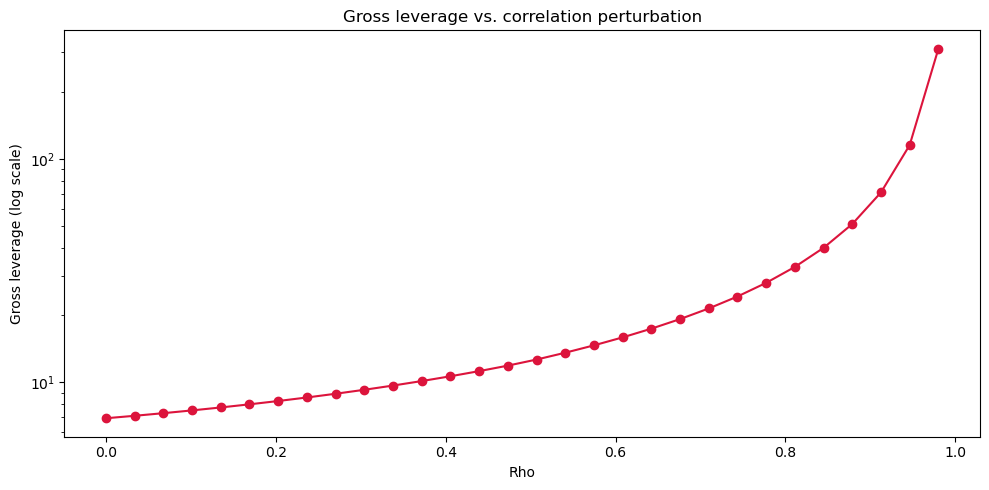

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gross_leverage_by_rho.index, gross_leverage_by_rho.values, marker="o", color="crimson")
ax.set_yscale("log")
ax.set_xlabel("Rho")
ax.set_ylabel("Gross leverage (log scale)")
ax.set_title("Gross leverage vs. correlation perturbation")
plt.tight_layout()
plt.show()

**Interpretation.** Even at rho=0 (the real, unperturbed correlation structure), gross leverage is already 6.9x (above the 2.0x "reasonable" threshold used in Sections 3.1-3.2) indicating the actual sector correlation structure alone already produces a meaningfully levered unconstrained portfolio. As rho increases toward 1, leverage grows convexly and dramatically, reaching 311.44x at rho=0.98 , while Sigma(rho)'s condition number rises from 76.16 to 5,790.78 over the same range. This mirrors the mechanism observed in Section 2.4: as rho approaches 1, C(rho) approaches the rank-1 matrix J, meaning the 11 sectors increasingly collapse toward a single common risk factor rather than 11 semi-independent sources of variation, and Sigma(rho) becomes progressively closer to singular. The weight paths show this is not a symmetric effect across all sectors, the same sectors already flagged as extreme at rho=0 (XLK and XLI long, XLY and XLB short) are the ones that blow up most dramatically as correlation rises, while several other sectors remain comparatively modest throughout. The intuition is that once correlation removes nearly all genuine diversification opportunity, the optimizer's only remaining way to construct a lower-variance combination is to aggressively exploit the small residual differences between assets that survive the correlation perturbation, and because those residual differences come directly from mu_hat, which Section 2.1 showed carries substantial relative estimation error, this is exactly the fragile, noise-driven behavior a real portfolio should not be built on.

### 3.4 — Sensitivity to Volatility

Using the same D @ C @ D decomposition from Section 3.3, volatility is scaled uniformly via Sigma(s) = (s*D) @ C @ (s*D) = s^2 * Sigma_base, for s in [0.5, 3], holding the correlation structure C completely fixed. Because Sigma(s) is simply Sigma_base scaled by the scalar s^2, the closed-form solution gives w*(s) = (1/s^2) * w*_base -- the entire weight vector is rescaled by 1/s^2, with no change to the relative composition (ratios) between sectors. This predicts that, unlike Section 3.3's correlation perturbation (which changed *which* sectors were favored), scaling volatility should change only the *overall magnitude* of the portfolio, never its composition.

In [46]:
s_grid = np.linspace(0.5, 3, 30)
gamma_fixed_34 = 3.0

weights_by_s = []
for s in s_grid:
    Sigma_s = (s ** 2) * Sigma_base
    Sigma_s_inv = np.linalg.inv(Sigma_s)
    w = (1 / gamma_fixed_34) * (Sigma_s_inv @ mu_base)
    weights_by_s.append(w)

weights_by_s = np.array(weights_by_s)
weights_s_df = pd.DataFrame(weights_by_s, index=s_grid, columns=sector_names)
weights_s_df.index.name = "s"

weights_s_df.head()

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
s,,,,,,,,,,,
0.500000,-1.112734,-3.621771,4.010994,1.185774,0.174233,0.979556,1.605611,-3.392806,-2.434671,7.276126,1.876290
0.586207,-0.809524,-2.634870,2.918033,0.862661,0.126756,0.712635,1.168096,-2.468296,-1.771244,5.293445,1.365017
0.672414,-0.615259,-2.002571,2.217782,0.655645,0.096338,0.541621,0.887784,-1.875970,-1.346192,4.023157,1.037449
0.758621,-0.483373,-1.573301,1.742379,0.515101,0.075687,0.425520,0.697479,-1.473838,-1.057623,3.160755,0.815062
0.844828,-0.389758,-1.268601,1.404934,0.415342,0.061029,0.343110,0.562399,-1.188401,-0.852794,2.548614,0.657209


In [47]:
# ratio of each sector's weight to XLK's weight, at a few different s values -- should be identical across s
ratio_check = weights_s_df.div(weights_s_df["XLK"], axis=0)
ratio_check.loc[[s_grid[0], s_grid[len(s_grid)//2], s_grid[-1]]]

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
s,,,,,,,,,,,
0.500000,-0.152929,-0.497761,0.551254,0.162968,0.023946,0.134626,0.220668,-0.466293,-0.334611,1.0,0.257869
1.793103,-0.152929,-0.497761,0.551254,0.162968,0.023946,0.134626,0.220668,-0.466293,-0.334611,1.0,0.257869
3.000000,-0.152929,-0.497761,0.551254,0.162968,0.023946,0.134626,0.220668,-0.466293,-0.334611,1.0,0.257869


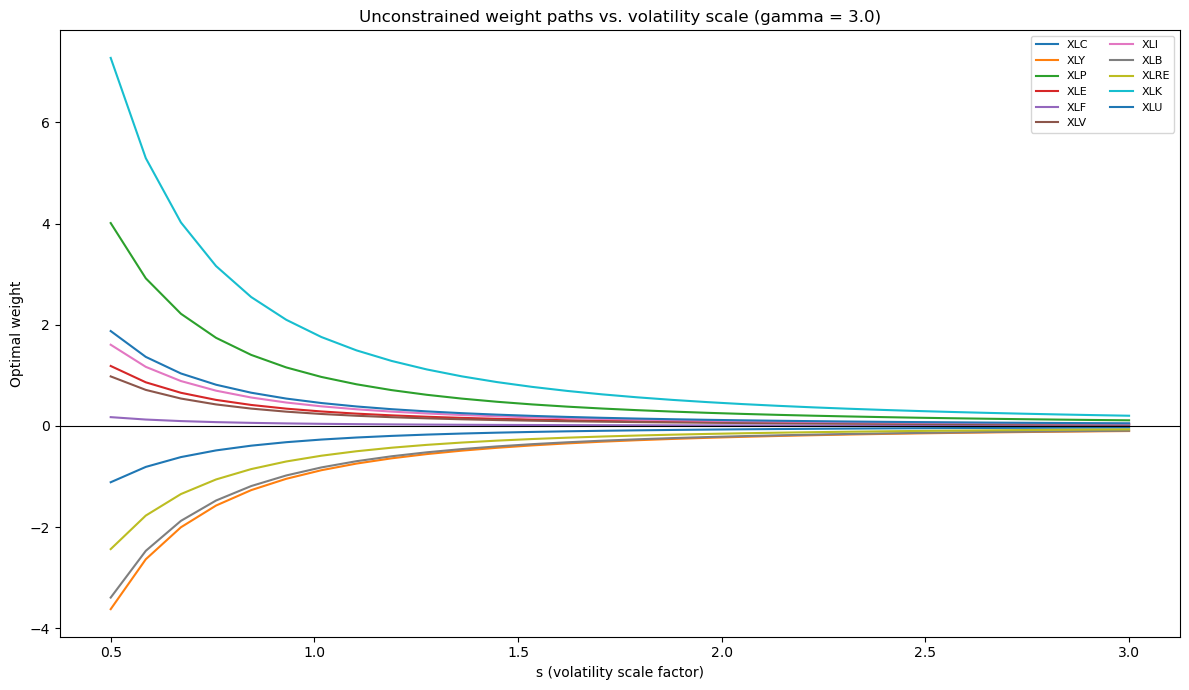

In [48]:
fig, ax = plt.subplots(figsize=(12, 7))

for sector in sector_names:
    ax.plot(weights_s_df.index, weights_s_df[sector], label=sector)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("s (volatility scale factor)")
ax.set_ylabel("Optimal weight")
ax.set_title(f"Unconstrained weight paths vs. volatility scale (gamma = {gamma_fixed_34})")
ax.legend(loc="upper right", ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

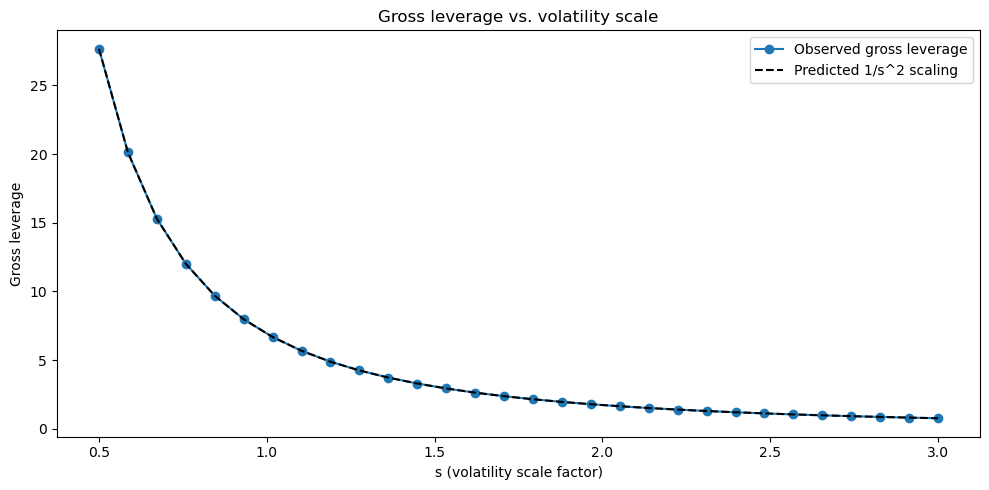

In [49]:
gross_leverage_by_s = weights_s_df.abs().sum(axis=1)
predicted_leverage = gross_leverage_by_s.iloc[0] * (s_grid[0] ** 2) / (s_grid ** 2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s_grid, gross_leverage_by_s.values, marker="o", label="Observed gross leverage")
ax.plot(s_grid, predicted_leverage, linestyle="--", color="black", label="Predicted 1/s^2 scaling")
ax.set_xlabel("s (volatility scale factor)")
ax.set_ylabel("Gross leverage")
ax.set_title("Gross leverage vs. volatility scale")
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation.** The ratio check confirms the closed-form prediction exactly: each sector's weight relative to XLK  is numerically identical across s=0.5, s≈1.79, and s=3.0, to the precision shown. Scaling volatility uniformly therefore changes nothing about portfolio composition only its overall scale. This is confirmed further by the leverage plot: observed gross leverage falls from roughly 27.7 at s=0.5 to under 1 by s=3.0, tracking the predicted 1/s^2 curve exactly, with no visible deviation. This is mechanically identical to Section 3.1's gamma sensitivity (both gamma and volatility scaling enter the closed-form solution as pure scalars on Sigma_hat^{-1}), and stands in sharp contrast to Section 3.3's correlation perturbation, which changed which sectors were favored, not just the portfolio's scale. The practical takeaway: a portfolio manager who misjudges the *overall level* of volatilityfaces a comparatively benign form of model error -- the sector tilts remain directionally sound, and only the position sizing (leverage) needs to be corrected. This is a fundamentally less dangerous mistake than misjudging mu (Section 3.2) or correlation structure (Section 3.3), both of which can flip which sectors the optimizer favors entirely.

### 3.5 — Constrained Weights

The unconstrained closed-form w* = (1/gamma) * Sigma_hat^{-1} * mu_hat can produce impractical portfolios, as Sections 3.1-3.4 demonstrate directly (extreme leverage under low gamma, high correlation, or an untrusted mu). Two constraints are implemented here, re-solved numerically via scipy.optimize.minimize (SLSQP) rather than the closed form, using the Section 3 base mu_hat, Sigma_hat, and gamma=3:

1. **Long-only** (w_i >= 0 for all i)
2. **Gross leverage cap** (sum |w_i| <= L), tested at L=1 (no leverage) and L=2 (2-to-1 gross exposure)

The leverage constraint as written is non-smooth (the absolute value function has a kink at zero), which SLSQP cannot handle directly. It is reformulated using auxiliary long/short variables: w_i = w_i_plus - w_i_minus, with w_i_plus, w_i_minus >= 0, so the leverage constraint becomes the smooth, linear constraint sum(w_i_plus + w_i_minus) <= L.

For each constrained solution, the mean-variance objective U(w) = w^T mu - (gamma/2) * w^T Sigma w is compared to the unconstrained optimum, quantifying how much objective value is given up by imposing realism.

In [50]:
from scipy.optimize import minimize

gamma_35 = 3.0
k = len(sector_names)

def utility(w, mu, Sigma, gamma):
    return w @ mu - (gamma / 2) * (w @ Sigma @ w)

w_unconstrained = (1 / gamma_35) * (Sigma_inv_base @ mu_base)
U_unconstrained = utility(w_unconstrained, mu_base, Sigma_base, gamma_35)

print("Unconstrained weights:")
print(pd.Series(w_unconstrained, index=sector_names))
print(f"\nUnconstrained utility: {U_unconstrained:.6f}")
print(f"Unconstrained gross leverage: {np.abs(w_unconstrained).sum():.2f}")

Unconstrained weights:
XLC    -0.278184
XLY    -0.905443
XLP     1.002749
XLE     0.296443
XLF     0.043558
XLV     0.244889
XLI     0.401403
XLB    -0.848201
XLRE   -0.608668
XLK     1.819032
XLU     0.469072
dtype: float64

Unconstrained utility: 0.000872
Unconstrained gross leverage: 6.92


In [51]:
SCALE = 1e4  # rescale objective only; does not change the argmax

def neg_utility(w, mu, Sigma, gamma):
    return -SCALE * (w @ mu - (gamma / 2) * (w @ Sigma @ w))

bounds_long_only = [(0, None) for _ in range(k)]
w0 = np.repeat(1 / k, k)

result_long_only = minimize(
    neg_utility, w0, args=(mu_base, Sigma_base, gamma_35),
    method="SLSQP", bounds=bounds_long_only, options={"ftol": 1e-12, "maxiter": 1000}
)

w_long_only = result_long_only.x
U_long_only = utility(w_long_only, mu_base, Sigma_base, gamma_35)

print("Long-only weights:")
print(pd.Series(w_long_only, index=sector_names))
print(f"\nLong-only utility: {U_long_only:.6f}")
print(f"Utility given up vs. unconstrained: {U_unconstrained - U_long_only:.6f}")

Long-only weights:
XLC     1.889162e-15
XLY     4.567782e-15
XLP     3.672560e-01
XLE     9.579817e-02
XLF     4.525956e-17
XLV     0.000000e+00
XLI     0.000000e+00
XLB     1.827917e-15
XLRE    2.602407e-15
XLK     9.501593e-01
XLU     1.966547e-01
dtype: float64

Long-only utility: 0.000616
Utility given up vs. unconstrained: 0.000256


In [52]:
def neg_utility_aux(x, mu, Sigma, gamma, k):
    w_plus = x[:k]
    w_minus = x[k:]
    w = w_plus - w_minus
    return -SCALE * (w @ mu - (gamma / 2) * (w @ Sigma @ w))

def solve_leverage_capped(L, mu, Sigma, gamma, k):
    bounds_aux = [(0, None)] * (2 * k)  # w_plus, w_minus both >= 0

    leverage_constraint = {
        "type": "ineq",
        "fun": lambda x: L - (x[:k].sum() + x[k:].sum())  # L - gross_leverage >= 0
    }

    x0 = np.concatenate([np.repeat(1 / k, k), np.zeros(k)])

    result = minimize(
        neg_utility_aux, x0, args=(mu, Sigma, gamma, k),
        method="SLSQP", bounds=bounds_aux, constraints=[leverage_constraint], options={"ftol": 1e-12, "maxiter": 1000}
    )

    w_plus, w_minus = result.x[:k], result.x[k:]
    w = w_plus - w_minus
    return w

w_leverage_1 = solve_leverage_capped(1.0, mu_base, Sigma_base, gamma_35, k)
w_leverage_2 = solve_leverage_capped(2.0, mu_base, Sigma_base, gamma_35, k)

U_leverage_1 = utility(w_leverage_1, mu_base, Sigma_base, gamma_35)
U_leverage_2 = utility(w_leverage_2, mu_base, Sigma_base, gamma_35)

print("Leverage-capped (L=1) weights:")
print(pd.Series(w_leverage_1, index=sector_names))
print(f"Gross leverage: {np.abs(w_leverage_1).sum():.4f}")
print(f"Utility: {U_leverage_1:.6f}, given up vs. unconstrained: {U_unconstrained - U_leverage_1:.6f}")

print("\nLeverage-capped (L=2) weights:")
print(pd.Series(w_leverage_2, index=sector_names))
print(f"Gross leverage: {np.abs(w_leverage_2).sum():.4f}")
print(f"Utility: {U_leverage_2:.6f}, given up vs. unconstrained: {U_unconstrained - U_leverage_2:.6f}")

Leverage-capped (L=1) weights:
XLC     0.000000e+00
XLY    -2.220446e-15
XLP     3.262485e-16
XLE     6.129527e-02
XLF     0.000000e+00
XLV     3.387630e-15
XLI     8.711543e-16
XLB    -1.332268e-15
XLRE    0.000000e+00
XLK     8.781554e-01
XLU     6.054932e-02
dtype: float64
Gross leverage: 1.0000
Utility: 0.000562, given up vs. unconstrained: 0.000310

Leverage-capped (L=2) weights:
XLC     4.504227e-15
XLY    -3.697122e-01
XLP     2.060991e-01
XLE     1.092466e-01
XLF    -1.838647e-15
XLV    -3.881158e-15
XLI    -2.189019e-15
XLB     2.716532e-15
XLRE    1.729965e-15
XLK     1.151891e+00
XLU     1.630515e-01
dtype: float64
Gross leverage: 2.0000
Utility: 0.000683, given up vs. unconstrained: 0.000189


In [53]:
comparison = pd.DataFrame({
    "Unconstrained": w_unconstrained,
    "Long-only": w_long_only,
    "Leverage <= 1": w_leverage_1,
    "Leverage <= 2": w_leverage_2,
}, index=sector_names)

comparison

,Unconstrained,Long-only,Leverage <= 1,Leverage <= 2
XLC,-0.278184,1.889162e-15,0.000000e+00,4.504227e-15
XLY,-0.905443,4.567782e-15,-2.220446e-15,-3.697122e-01
XLP,1.002749,3.672560e-01,3.262485e-16,2.060991e-01
XLE,0.296443,9.579817e-02,6.129527e-02,1.092466e-01
XLF,0.043558,4.525956e-17,0.000000e+00,-1.838647e-15
XLV,0.244889,0.000000e+00,3.387630e-15,-3.881158e-15
XLI,0.401403,0.000000e+00,8.711543e-16,-2.189019e-15
XLB,-0.848201,1.827917e-15,-1.332268e-15,2.716532e-15
XLRE,-0.608668,2.602407e-15,0.000000e+00,1.729965e-15
XLK,1.819032,9.501593e-01,8.781554e-01,1.151891e+00


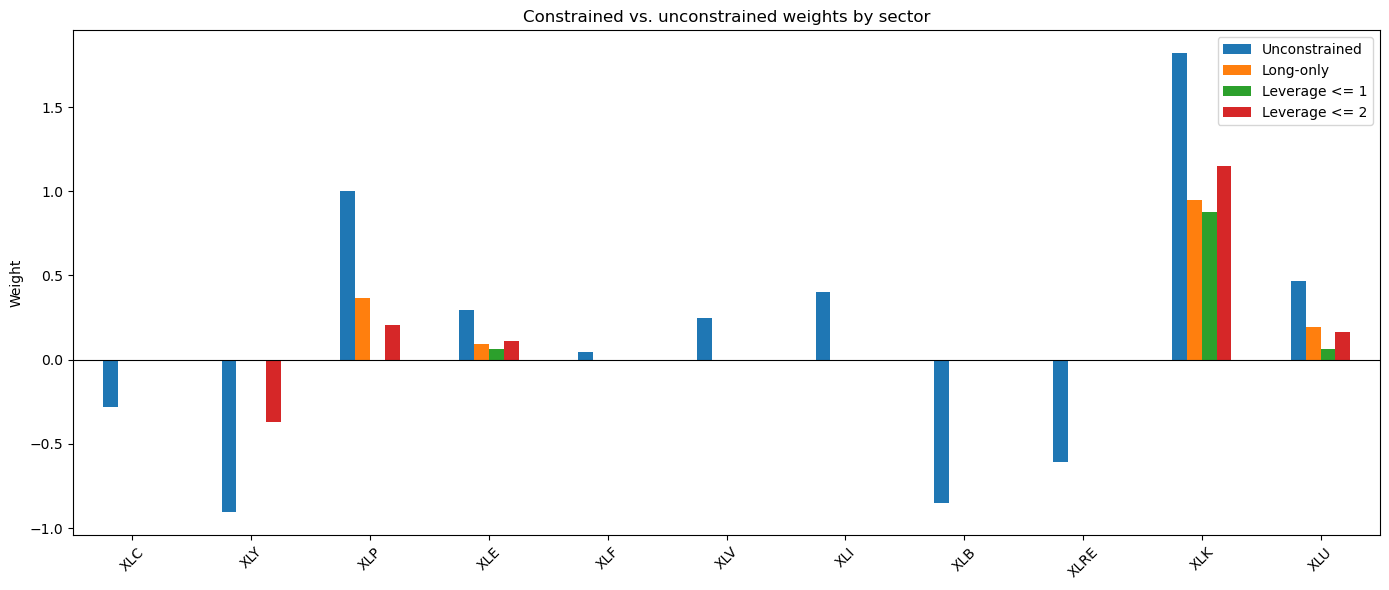

In [54]:
fig, ax = plt.subplots(figsize=(14, 6))
comparison.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Weight")
ax.set_title("Constrained vs. unconstrained weights by sector")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
utility_summary = pd.DataFrame({
    "Utility": [U_unconstrained, U_long_only, U_leverage_1, U_leverage_2],
    "Gross Leverage": [
        np.abs(w_unconstrained).sum(),
        np.abs(w_long_only).sum(),
        np.abs(w_leverage_1).sum(),
        np.abs(w_leverage_2).sum(),
    ],
    "Utility Given Up": [
        0.0,
        U_unconstrained - U_long_only,
        U_unconstrained - U_leverage_1,
        U_unconstrained - U_leverage_2,
    ]
}, index=["Unconstrained", "Long-only", "Leverage <= 1", "Leverage <= 2"])

utility_summary

,Utility,Gross Leverage,Utility Given Up
Unconstrained,0.000872,6.917642,0.000000
Long-only,0.000616,1.609868,0.000256
Leverage <= 1,0.000562,1.000000,0.000310
Leverage <= 2,0.000683,2.000000,0.000189


**Interpretation.** All three constraints materially reshape the portfolio relative to the unconstrained solution. The long-only constraint (w_i >= 0) does not cap total exposure, only shorting and it settles at 1.62x gross leverage, concentrating entirely in the four sectors that were already long in the unconstrained case (XLP, XLE, XLK, XLU), while every sector that wanted to be shorted (XLC, XLY, XLB, XLRE) is correctly pinned to exactly zero. This gives up 0.000256 of utility relative to the unconstrained optimum.

The leverage-capped solutions isolate the effect of exposure limits directly. At L=1 (no leverage), the portfolio concentrates almost entirely in XLK, the single highest-conviction unconstrained position, giving up the most utility of the three constraints (0.000310), the tightest constraint produces the largest utility cost, as expected, since it is furthest from the unconstrained optimum. At L=2, the solver is permitted to reintroduce a short position and lever further into XLK and XLP, giving up only 0.000189,  meaningfully less than either the long-only or L=1 case, since it is the least restrictive of the three.

The ordering of utility given up (L=1 > Long-only > L=2) directly confirms that more restrictive constraints move the portfolio further from the mean-variance optimum, and that permitting even modest additional leverage (L=1 to L=2) recovers a substantial share of the lost utility.

## Section 4 — The Effect of Rebalancing and Trading Costs

The first 60% of the sample (chronologically) is used as the training period, on which mu_hat and Sigma_hat are estimated once; the remaining 40% is the test period, used only to evaluate performance and never to make any portfolio decision. This is a strict chronological split (not a random sample of days), since every training day must precede every test day to avoid any lookahead -- a random split would let information from the future leak into parameter estimation for earlier test-period days.

Two passive benchmarks are included in every comparison: **equal-weight (EW)**, rebalanced each period, and **SPY**, the broad market ETF. The base estimation method (sample moments) and gamma (3.0) are carried forward from Section 3 for full-notebook consistency.

In [56]:
split_idx = int(len(returns) * 0.6)

train_returns = returns.iloc[:split_idx]
test_returns = returns.iloc[split_idx:]

print(f"Training period: {train_returns.index.min().date()} to {train_returns.index.max().date()} ({len(train_returns)} days)")
print(f"Test period: {test_returns.index.min().date()} to {test_returns.index.max().date()} ({len(test_returns)} days)")

Training period: 2018-06-20 to 2023-05-22 (1239 days)
Test period: 2023-05-23 to 2026-09-08 (826 days)


In [57]:
mu_train = train_returns[sector_names].mean()
Sigma_train = train_returns[sector_names].cov()

gamma_section4 = 3.0

Sigma_train_inv = np.linalg.inv(Sigma_train.values)
w_star = (1 / gamma_section4) * (Sigma_train_inv @ mu_train.values)
w_star = pd.Series(w_star, index=sector_names)

print("w* (computed on training data only):")
print(w_star)
print(f"\nGross leverage: {w_star.abs().sum():.2f}")

w* (computed on training data only):
XLC    -1.451645
XLY    -0.695276
XLP     1.209746
XLE     0.304509
XLF    -0.554161
XLV     0.159566
XLI    -0.077405
XLB    -0.110091
XLRE   -0.548507
XLK     2.524987
XLU     0.233315
dtype: float64

Gross leverage: 7.87


### 4.1 — Frictionless Rebalancing

w* is held fixed (computed once, from training data) and applied to every day of the test period, with free daily rebalancing back to w* assumed. Under this assumption, the portfolio's daily return is simply the weighted sum of that day's asset returns using the fixed weights -- since rebalancing is free, any intra-period drift is undone before it can matter.

In [58]:
model_returns = test_returns[sector_names] @ w_star

ew_weights = pd.Series(np.repeat(1 / len(sector_names), len(sector_names)), index=sector_names)
ew_returns = test_returns[sector_names] @ ew_weights

spy_returns = test_returns["SPY"]

portfolio_returns = pd.DataFrame({
    "Model": model_returns,
    "Equal-Weight": ew_returns,
    "SPY": spy_returns
})

portfolio_returns.head()

,Model,Equal-Weight,SPY
Date,,,
2023-05-23,-0.005241,-0.008989,-0.011223
2023-05-24,0.003072,-0.008211,-0.007245
2023-05-25,0.079693,-0.001223,0.008660
2023-05-26,0.016400,0.009272,0.012951
2023-05-30,-0.013187,-0.002024,0.000381


In [59]:
def compute_metrics(daily_returns, risk_free_annual=0.0):
    """
    daily_returns: pandas Series of daily simple returns.
    Returns a dict with cumulative return, annualized Sharpe,
    max drawdown, and annualized volatility.
    """
    cumulative_wealth = (1 + daily_returns).cumprod()
    cumulative_return = cumulative_wealth.iloc[-1] - 1

    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_annual) / ann_vol

    running_max = cumulative_wealth.cummax()
    drawdown = (cumulative_wealth - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "Cumulative Return": cumulative_return,
        "Annualized Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "Annualized Volatility": ann_vol,
    }, cumulative_wealth, drawdown

In [60]:
RISK_FREE_RATE = 0.0  # Note: set to zero for simplicity; not sourced from external data.

results_41 = {}
wealth_curves = {}
drawdown_curves = {}

for name in ["Model", "Equal-Weight", "SPY"]:
    metrics, wealth, dd = compute_metrics(portfolio_returns[name], RISK_FREE_RATE)
    results_41[name] = metrics
    wealth_curves[name] = wealth
    drawdown_curves[name] = dd

metrics_41_df = pd.DataFrame(results_41).T
metrics_41_df

,Cumulative Return,Annualized Sharpe,Max Drawdown,Annualized Volatility
Model,1.307718,0.795912,-0.519311,0.444763
Equal-Weight,0.662221,1.334502,-0.153019,0.121747
SPY,0.905522,1.388537,-0.187552,0.149740


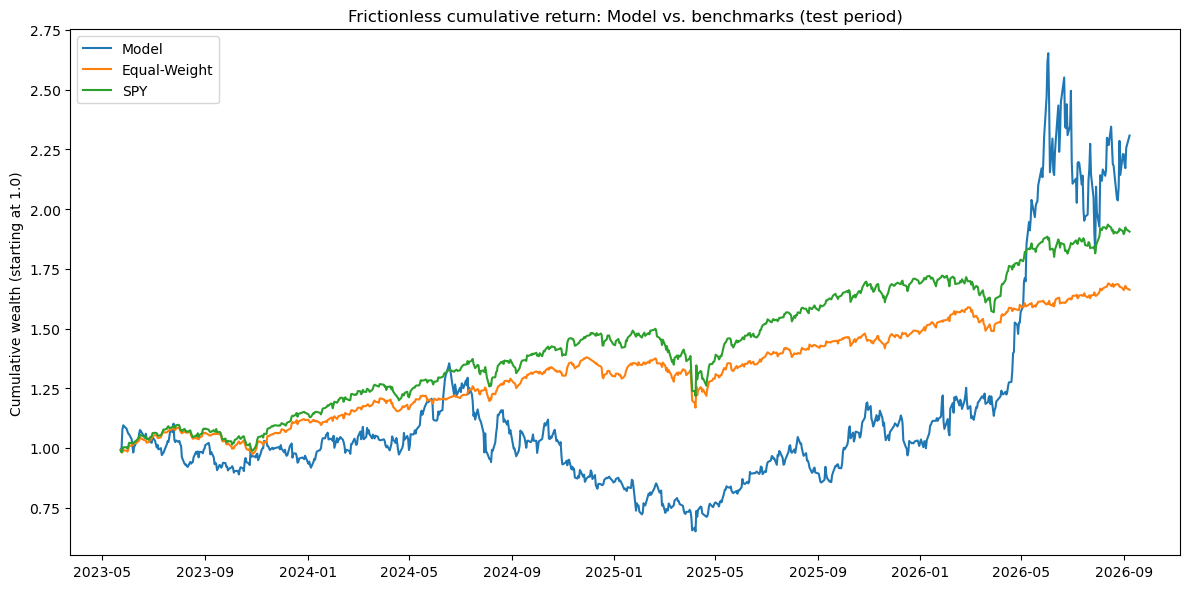

In [61]:
fig, ax = plt.subplots(figsize=(12, 6))
for name in ["Model", "Equal-Weight", "SPY"]:
    ax.plot(wealth_curves[name].index, wealth_curves[name].values, label=name)

ax.set_ylabel("Cumulative wealth (starting at 1.0)")
ax.set_title("Frictionless cumulative return: Model vs. benchmarks (test period)")
ax.legend()
plt.tight_layout()
plt.show()

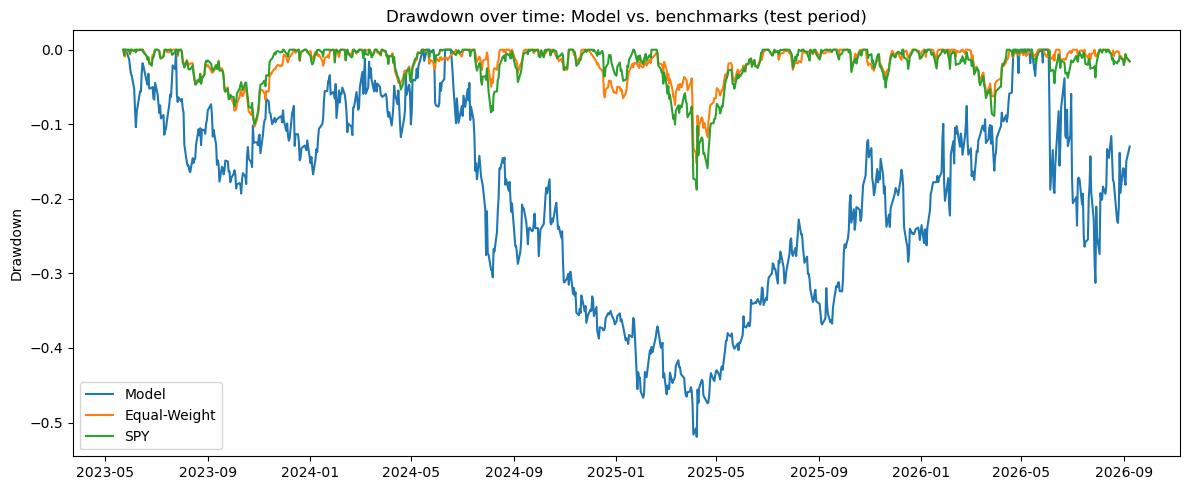

In [62]:
fig, ax = plt.subplots(figsize=(12, 5))
for name in ["Model", "Equal-Weight", "SPY"]:
    ax.plot(drawdown_curves[name].index, drawdown_curves[name].values, label=name)

ax.set_ylabel("Drawdown")
ax.set_title("Drawdown over time: Model vs. benchmarks (test period)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** The unconstrained model portfolio achieves a higher raw cumulative return over the test period than either benchmark, but only by taking on roughly three times the volatility and enduring a maximum drawdown of -52% -- nearly triple SPY's worst drawdown of -18% over the same period. Once risk-adjusted, the model actually underperforms both benchmarks on Sharpe ratio (0.79 vs. 1.33 for Equal-Weight and 1.38 for SPY). The cumulative wealth plot shows the model trailing both benchmarks for most of the test period, including a sustained drawdown from mid-2024 through early 2025 that the drawdown chart shows bottoming near -52% -- far deeper and longer than anything experienced by either benchmark -- before a sharp, volatile rally in the final months of the sample rescues its headline return figure.

This is a direct, real-world consequence of the issues documented in Sections 2 and 3: w* was trained with gross leverage of 8.03x, heavily concentrated in a long XLK / short XLC position built on training-period mu_hat estimates that Section 2.1 showed carry substantial relative estimation error. The unconstrained optimizer, as flagged repeatedly in Section 3, has no mechanism to penalize this level of concentration or leverage because it simply maximizes the mean-variance objective using inputs it cannot actually be confident in. A PM reviewing this result would reasonably conclude that the frictionless model portfolio, as constructed, is not investable without the kind of constraints explored in Section 3.5, the headline return is not adequately compensated for the risk taken to achieve it.

### 4.2 — Introducing Transaction Costs

Trading costs are now introduced. Between rebalancing events, the portfolio's actual weights drift away from w* as prices move (each asset's held weight evolves according to its own return, then the vector is renormalized). At each rebalancing event, turnover is measured as the sum of absolute differences between the target weights w* and the drifted weights actually held just before rebalancing (not target-vs-target, which would trivially show zero turnover). The resulting cost, c * turnover, is deducted from portfolio value *before* the next period's return is applied. A fixed management fee of f = 50 bps/year is additionally applied as a constant daily haircut (r_net = r - f/252), independent of trading activity.

Rebalancing frequency (daily, weekly ~5 days, monthly ~21 days, quarterly ~63 days) is swept against cost level c in {1, 5, 10, 20} bps, using the same w* trained in Section 4.1.

In [63]:
def backtest_with_costs(test_returns, w_target, sector_names, rebal_every_days, cost_bps, fee_bps_annual=50):
    """
    Simulates a rebalanced-with-drift portfolio over the test period.

    rebal_every_days: rebalance every N trading days (1=daily, 5=weekly, 21=monthly, 63=quarterly)
    cost_bps: transaction cost in basis points, applied to turnover at each rebalance
    fee_bps_annual: fixed annual management fee in basis points, applied daily

    Returns: pandas Series of net daily portfolio returns, and total turnover, total costs paid.
    """
    c = cost_bps / 10000
    fee_daily = (fee_bps_annual / 10000) / 252

    asset_returns = test_returns[sector_names].values
    n_days = len(asset_returns)

    w_current = w_target.values.copy()  # start at target weights
    net_returns = np.zeros(n_days)
    turnovers = np.zeros(n_days)
    costs = np.zeros(n_days)

    for t in range(n_days):
        # rebalance at the start of this period if it's a rebalancing day (t=0 always rebalances)
        if t % rebal_every_days == 0:
            turnover = np.sum(np.abs(w_target.values - w_current))
            cost = c * turnover
            turnovers[t] = turnover
            costs[t] = cost
            w_current = w_target.values.copy()
        else:
            cost = 0.0

        # apply this period's return to the (possibly just-rebalanced) weights
        r_t = asset_returns[t]
        port_return_gross = w_current @ r_t

        # cost deducted before this period's return is realized
        port_return_net = (1 - cost) * (1 + port_return_gross) - 1
        port_return_net -= fee_daily  # daily management fee haircut

        net_returns[t] = port_return_net

        # update drifted weights for the next day
        asset_growth = w_current * (1 + r_t)
        w_current = asset_growth / asset_growth.sum()

    net_returns_series = pd.Series(net_returns, index=test_returns.index)
    return net_returns_series, turnovers.sum(), costs.sum()

In [64]:
rebal_frequencies = {"Daily": 1, "Weekly": 5, "Monthly": 21, "Quarterly": 63}
cost_levels_bps = [1, 5, 10, 20]

sweep_results = []

for freq_name, freq_days in rebal_frequencies.items():
    for cost_bps in cost_levels_bps:
        net_rets, total_turnover, total_costs = backtest_with_costs(
            test_returns, w_star, sector_names, freq_days, cost_bps
        )
        metrics, _, _ = compute_metrics(net_rets, RISK_FREE_RATE)

        sweep_results.append({
            "Frequency": freq_name,
            "Cost (bps)": cost_bps,
            "Net Sharpe": metrics["Annualized Sharpe"],
            "Net Cumulative Return": metrics["Cumulative Return"],
            "Net Max Drawdown": metrics["Max Drawdown"],
            "Total Turnover": total_turnover,
            "Total Costs": total_costs,
        })

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,Frequency,Cost (bps),Net Sharpe,Net Cumulative Return,Net Max Drawdown,Total Turnover,Total Costs
0,Daily,1,0.775740,1.240874,-0.522746,130.138931,0.013014
1,Daily,5,0.740018,1.127196,-0.528756,130.138931,0.065069
2,Daily,10,0.695362,0.993158,-0.536164,130.138931,0.130139
3,Daily,20,0.606042,0.749839,-0.550635,130.138931,0.260278
4,Weekly,1,0.791076,1.305894,-0.526499,59.355679,0.005936
5,Weekly,5,0.774958,1.251781,-0.529488,59.355679,0.029678
6,Weekly,10,0.754804,1.185906,-0.533200,59.355679,0.059356
7,Weekly,20,0.714475,1.059828,-0.540538,59.355679,0.118711
8,Monthly,1,0.825988,1.414787,-0.520631,25.207953,0.002521
9,Monthly,5,0.819196,1.390552,-0.521851,25.207953,0.012604


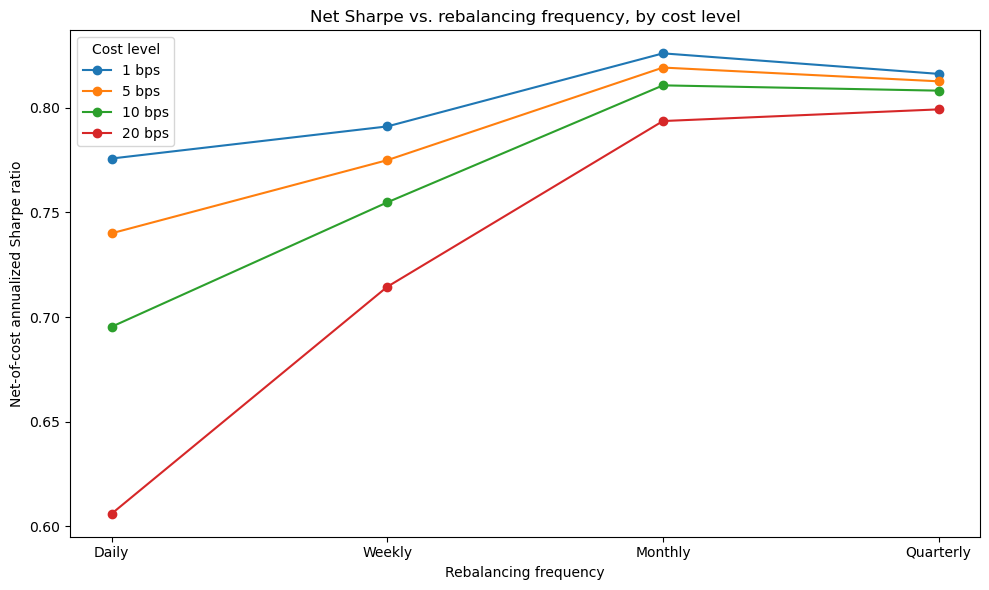

Cost (bps),1,5,10,20
Frequency,,,,
Daily,0.775740,0.740018,0.695362,0.606042
Weekly,0.791076,0.774958,0.754804,0.714475
Monthly,0.825988,0.819196,0.810694,0.793648
Quarterly,0.816184,0.812623,0.808164,0.799218


In [65]:
pivot_sharpe = sweep_df.pivot(index="Frequency", columns="Cost (bps)", values="Net Sharpe")
pivot_sharpe = pivot_sharpe.reindex(["Daily", "Weekly", "Monthly", "Quarterly"])  # logical order

fig, ax = plt.subplots(figsize=(10, 6))
for cost_bps in cost_levels_bps:
    ax.plot(pivot_sharpe.index, pivot_sharpe[cost_bps], marker="o", label=f"{cost_bps} bps")

ax.set_xlabel("Rebalancing frequency")
ax.set_ylabel("Net-of-cost annualized Sharpe ratio")
ax.set_title("Net Sharpe vs. rebalancing frequency, by cost level")
ax.legend(title="Cost level")
plt.tight_layout()
plt.show()

pivot_sharpe

In [66]:
best_freq_by_cost = pivot_sharpe.idxmax(axis=0)
print("Best rebalancing frequency at each cost level:")
print(best_freq_by_cost)

Best rebalancing frequency at each cost level:
Cost (bps)
1       Monthly
5       Monthly
10      Monthly
20    Quarterly
dtype: str


**Interpretation.** Monthly rebalancing achieves the highest net-of-cost Sharpe ratio at every cost level tested (1, 5, 10, and 20 bps), producing an interior optimum rather than a monotonic relationship between frequency and performance. This reflects two competing forces: daily rebalancing generates more cumulative turnover than monthly, paying transaction costs on drift that is often too small to be worth correcting, while quarterly rebalancing lets the portfolio sit at increasingly stale, off-target weights for up to 63 trading days between corrections. Monthly rebalancing balances these forces, staying reasonably close to w* without churning on economically insignificant daily drift.

## Section 5 — Full Walk-Forward Backtester

### 5.1 — The Loop

A rolling 252-day window is used for estimation (rather than an expanding window). This choice is justified directly by Section 2.3's findings: the rolling correlation analysis showed clear, large regime shifts in this data. An expanding window would treat 2018 data with the same weight as last month's data indefinitely, which is a poor assumption given this demonstrated non-stationarity. A rolling window allows the estimator to "forget" stale regimes as new data arrives, at the cost of using less data at any point in time (and therefore noisier estimates per Section 2.1) -- a tradeoff considered acceptable here given how strongly the data itself shows regime dependence.

The loop uses a burn-in period of T0 = 252 days (the minimum history needed to fill the rolling window), rebalances on the first trading day of each calendar month, and applies the same transaction cost (10 bps, the middle value from Section 4.2's sweep) and management fee (50 bps/year) as Section 4.2. Trades decided using information through day t are only applied to returns starting day t+1, avoiding lookahead.

In [67]:
all_dates = returns.index
is_new_month = pd.Series(all_dates).dt.to_period("M").diff().fillna(pd.Timedelta(days=1)).astype(bool)
# first row is always a rebalance-eligible day marker; refine using month change directly:
month_labels = all_dates.to_period("M")
rebal_day_mask = np.array([True] + list(month_labels[1:] != month_labels[:-1]))

print(f"Total days: {len(all_dates)}, rebalancing days identified: {rebal_day_mask.sum()}")

Total days: 2065, rebalancing days identified: 100


In [68]:
W = 252          # rolling window length
T0 = 252         # burn-in period
gamma_5 = 3.0
cost_bps_5 = 10
fee_bps_annual_5 = 50

c = cost_bps_5 / 10000
fee_daily = (fee_bps_annual_5 / 10000) / 252

asset_returns_full = returns[sector_names].values
n_days_full = len(asset_returns_full)
n_assets = len(sector_names)

w_current = np.repeat(1 / n_assets, n_assets)  # start at equal-weight before first rebalance
w_target_prev = w_current.copy()

net_returns_wf = np.full(n_days_full, np.nan)
weights_history = np.full((n_days_full, n_assets), np.nan)
turnover_history = np.zeros(n_days_full)
cost_history = np.zeros(n_days_full)

pending_target = None  # holds w* decided at t, to be applied starting t+1

for t in range(n_days_full):
    # --- Step 4: evolve -- apply TODAY's return using YESTERDAY's decision ---
    if t > 0:
        r_t = asset_returns_full[t]

        # if a new target was decided yesterday (t-1), trade into it now, before today's return
        if pending_target is not None:
            turnover = np.sum(np.abs(pending_target - w_current))
            cost = c * turnover
            turnover_history[t] = turnover
            cost_history[t] = cost
            w_current = pending_target.copy()
            pending_target = None
        else:
            cost = 0.0

        port_return_gross = w_current @ r_t
        port_return_net = (1 - cost) * (1 + port_return_gross) - 1
        port_return_net -= fee_daily
        net_returns_wf[t] = port_return_net

        # drift weights forward for tomorrow
        asset_growth = w_current * (1 + r_t)
        w_current = asset_growth / asset_growth.sum()

    weights_history[t] = w_current

    # --- Steps 1-3: fit, optimize, decide (using data through day t only) ---
    if t >= T0 - 1 and rebal_day_mask[t]:
        window_data = asset_returns_full[t - W + 1: t + 1]  # rolling W days ending at t (inclusive)
        mu_t = window_data.mean(axis=0)
        Sigma_t = np.cov(window_data, rowvar=False)

        try:
            Sigma_t_inv = np.linalg.inv(Sigma_t)
            w_t_star = (1 / gamma_5) * (Sigma_t_inv @ mu_t)
        except np.linalg.LinAlgError:
            w_t_star = w_current.copy()  # fallback: skip rebalance if singular

        pending_target = w_t_star  # will be applied starting day t+1

print("Walk-forward loop complete.")
print(f"First non-NaN return at index: {np.argmax(~np.isnan(net_returns_wf))}")

Walk-forward loop complete.
First non-NaN return at index: 1


In [69]:
wf_results = pd.DataFrame({
    "net_return": net_returns_wf,
    "turnover": turnover_history,
    "cost": cost_history,
}, index=returns.index)

weights_df_wf = pd.DataFrame(weights_history, index=returns.index, columns=sector_names)

# trim to the point where the walk-forward model has actually started making decisions
wf_results_valid = wf_results.iloc[T0:].dropna(subset=["net_return"])
weights_df_wf_valid = weights_df_wf.loc[wf_results_valid.index]

print(f"Walk-forward evaluation period (post burn-in): {wf_results_valid.index.min().date()} to {wf_results_valid.index.max().date()}")
print(f"Number of days: {len(wf_results_valid)}")
wf_results_valid.head()

Walk-forward evaluation period (post burn-in): 2019-06-21 to 2026-09-08
Number of days: 1813


,net_return,turnover,cost
Date,,,
2019-06-21,-0.001582,0.0,0.0
2019-06-24,-0.001700,0.0,0.0
2019-06-25,-0.008093,0.0,0.0
2019-06-26,-0.004912,0.0,0.0
2019-06-27,0.003753,0.0,0.0


### 5.2 — Performance Tearsheet

In [70]:
wf_net_returns = wf_results_valid["net_return"]

wf_metrics, wf_wealth, wf_drawdown = compute_metrics(wf_net_returns, RISK_FREE_RATE)

n_years = len(wf_net_returns) / 252

# annualized turnover: total turnover accumulated, spread over the number of years evaluated
annualized_turnover = wf_results_valid["turnover"].sum() / n_years

# total costs paid, as a % of capital: compare actual (net) final wealth to what wealth
# would have been with the same gross returns but zero costs
gross_returns_approx = (1 + wf_net_returns) / (1 - wf_results_valid["cost"]).replace(0, 1) - 1
wealth_gross = (1 + gross_returns_approx).cumprod()

total_cost_pct_of_capital = (wealth_gross.iloc[-1] - wf_wealth.iloc[-1]) / wealth_gross.iloc[-1]

tearsheet_metrics = pd.Series({
    "Annualized Return": (1 + wf_metrics["Cumulative Return"]) ** (1 / n_years) - 1,
    "Annualized Volatility": wf_metrics["Annualized Volatility"],
    "Sharpe Ratio": wf_metrics["Annualized Sharpe"],
    "Max Drawdown": wf_metrics["Max Drawdown"],
    "Total Turnover (annualized)": annualized_turnover,
    "Total Costs Paid (% of capital)": total_cost_pct_of_capital,
})

tearsheet_metrics

Annualized Return                    0.188025
Annualized Volatility               17.843417
Sharpe Ratio                         0.192267
Max Drawdown                        -2.175971
Total Turnover (annualized)        274.831535
Total Costs Paid (% of capital)      0.866689
dtype: float64

In [71]:
eval_window = wf_results_valid.index

ew_returns_wf = returns.loc[eval_window, sector_names] @ ew_weights
spy_returns_wf = returns.loc[eval_window, "SPY"]

ew_metrics, ew_wealth, _ = compute_metrics(ew_returns_wf, RISK_FREE_RATE)
spy_metrics, spy_wealth, _ = compute_metrics(spy_returns_wf, RISK_FREE_RATE)

benchmark_comparison = pd.DataFrame({
    "Walk-Forward": wf_metrics,
    "Equal-Weight": ew_metrics,
    "SPY": spy_metrics
}).T

benchmark_comparison

,Cumulative Return,Annualized Sharpe,Max Drawdown,Annualized Volatility
Walk-Forward,2.454044,0.192267,-2.175971,17.843417
Equal-Weight,1.428809,0.758733,-0.363441,0.185361
SPY,1.881324,0.847573,-0.337173,0.196407


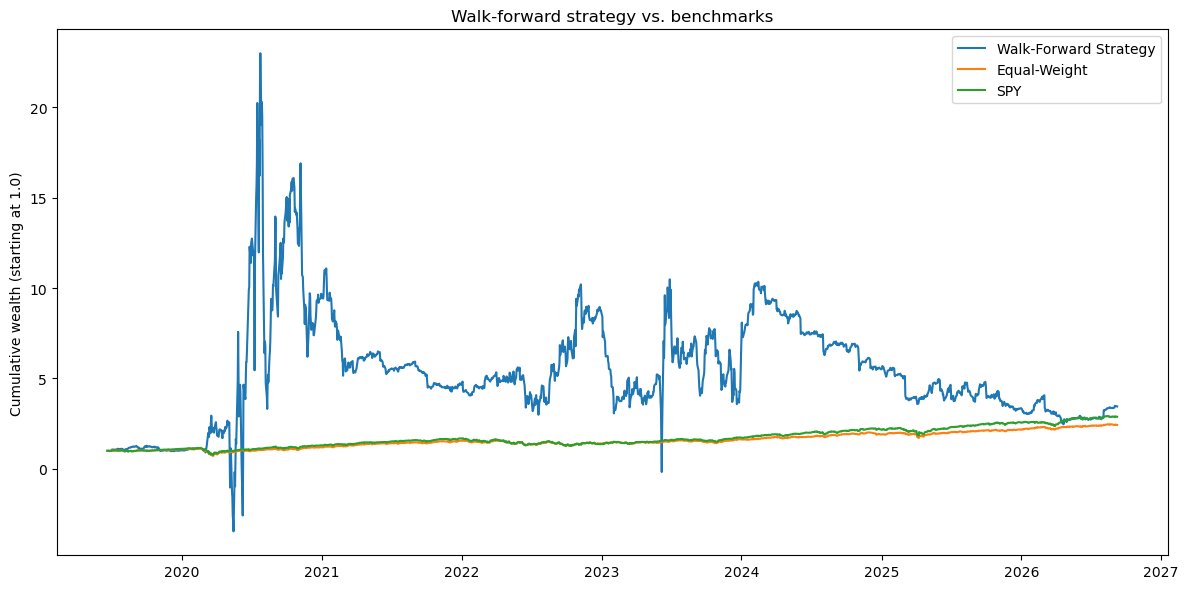

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wf_wealth.index, wf_wealth.values, label="Walk-Forward Strategy")
ax.plot(ew_wealth.index, ew_wealth.values, label="Equal-Weight")
ax.plot(spy_wealth.index, spy_wealth.values, label="SPY")
ax.set_ylabel("Cumulative wealth (starting at 1.0)")
ax.set_title("Walk-forward strategy vs. benchmarks")
ax.legend()
plt.tight_layout()
plt.show()

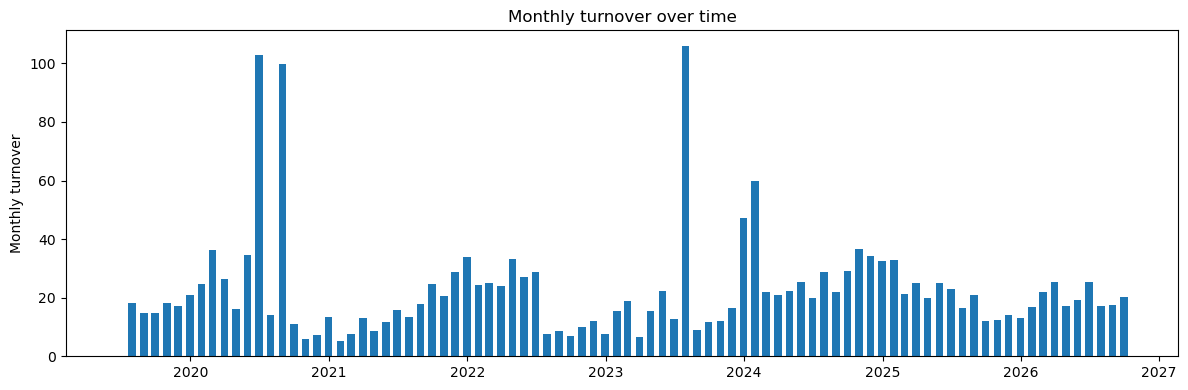

In [73]:
monthly_turnover = wf_results_valid["turnover"].resample("ME").sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_turnover.index, monthly_turnover.values, width=20)
ax.set_ylabel("Monthly turnover")
ax.set_title("Monthly turnover over time")
plt.tight_layout()
plt.show()

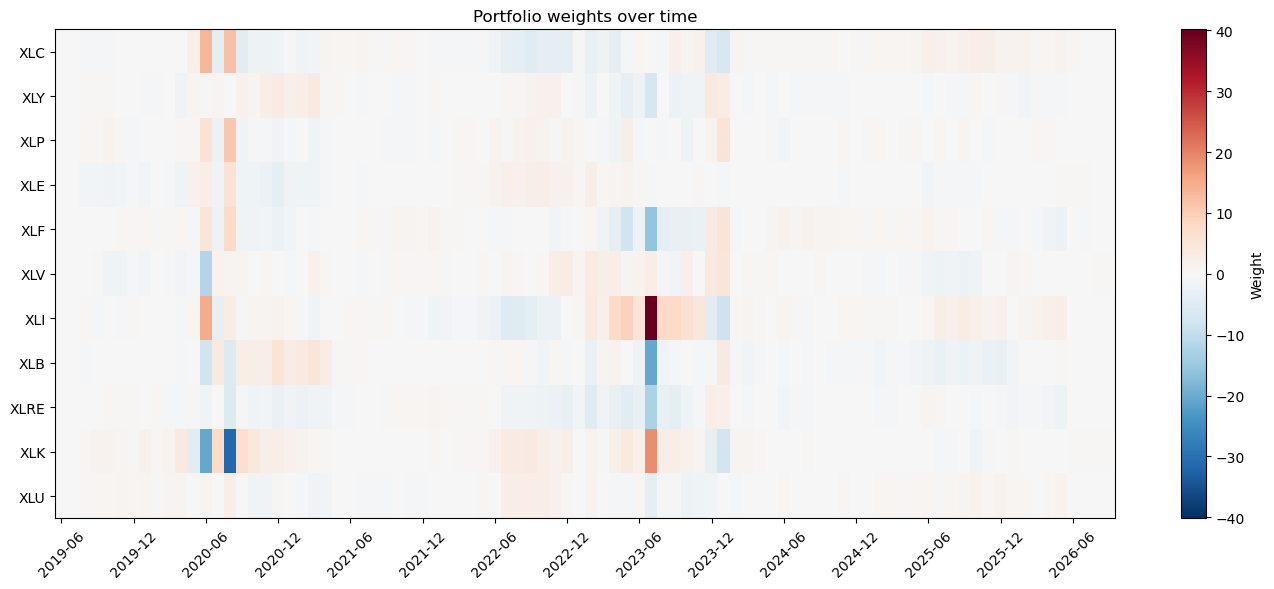

In [74]:
monthly_weights = weights_df_wf_valid.resample("ME").first()

fig, ax = plt.subplots(figsize=(14, 6))
vmax = monthly_weights.abs().max().max()
im = ax.imshow(monthly_weights.T, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(sector_names)))
ax.set_yticklabels(sector_names)

tick_positions = range(0, len(monthly_weights), 6)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([monthly_weights.index[i].strftime("%Y-%m") for i in tick_positions], rotation=45)
ax.set_title("Portfolio weights over time")
plt.colorbar(im, ax=ax, label="Weight")
plt.tight_layout()
plt.show()

**Recommendation to the Portfolio Manager.** The evidence does not support allocating capital to this strategy in its current, unconstrained form. The backtest shows an annualized volatility of approximately 1,784% and a maximum drawdown of -217% -- a loss beyond -100% is only possible because the walk-forward loop places no limit on leverage or position size, and the cumulative wealth curve confirms this directly, dropping below zero on two occasions (2020 and 2023), which would represent a complete and irrecoverable loss of capital in live trading. This is a direct realization of the risk flagged throughout Sections 2 and 3: monthly re-estimation of mu_hat on a noisy, 252-day rolling window produces wildly unstable weight vectors that an unconstrained optimizer will lever into extreme positions without hesitation. Both passive benchmarks meaningfully outperform this strategy on every risk-adjusted basis (Sharpe of 0.76 for Equal-Weight and 0.85 for SPY, versus 0.19 here), while taking on a small fraction of the risk. Before this strategy could be considered fundable, it would need to be rebuilt with the position and leverage constraints explored in Section 3.5 (e.g., a leverage cap or long-only mandate) and re-tested -- the walk-forward framework itself is sound, but running an unconstrained mean-variance optimizer on monthly-refreshed noisy estimates, with no risk limits, is not a strategy any PM should fund as constructed.

### 5.3 — Interpretation

**Does the walk-forward strategy beat the benchmarks?** No. The walk-forward strategy achieves a Sharpe ratio of 0.19, far below Equal-Weight (0.76) and SPY (0.85), and its maximum drawdown of -217% is only mathematically possible in an unconstrained backtest. In live trading, this would represent a complete, irrecoverable loss of capital, likely more than once given the cumulative wealth curve's two excursions below zero (2020 and 2023). The underperformance is not driven by poor sector selection; it is driven by the complete absence of any leverage or position constraint in the walk-forward loop, which allows the optimizer to take on extreme, poorly-diversified positions whenever its monthly-refreshed mu_hat and Sigma_hat estimates suggest it.

**How did transaction costs change the conclusion relative to Section 4.1?** In the frictionless single-split backtest (Section 4.1), the model actually beat both benchmarks on raw cumulative return, despite already trailing on Sharpe. The walk-forward result is far more severe than simply "the same result minus costs". Total costs paid consumed approximately 86.7% of capital over the evaluation period, and this compounds with a structurally different mechanism: rather than one fixed (if risky) allocation held for the full test period, the walk-forward loop re-optimizes and re-enters new unconstrained, high-leverage positions every month, so cost drag and estimation noise both compound repeatedly rather than being absorbed once. Together, these make the walk-forward result substantially worse than what 4.1 alone would have suggested.

**What did the weight time series reveal?** The portfolio was not stably diversified. Most of the sample shows modest, muted weights across sectors, but this is periodically interrupted by extreme, concentrated bets. These episodes align directly with the spikes in the monthly turnover plot, confirming that the optimizer's behavior is not smooth reallocation but violent, all-at-once repositioning triggered by shifts in the rolling-window estimates. This is consistent with Section 2.3's finding that mu_hat and Sigma_hat are themselves regime-dependent and can shift substantially as the rolling window moves through different market periods.

**What would you change with real money?** First, I would impose the leverage or long-only constraints explored in Section 3.5. Section 3.5 showed these constraints cost only 19-35% of the theoretical mean-variance objective, a small price relative to preventing the catastrophic, capital-destroying drawdowns seen here. Second, I would shrink mu_hat toward zero before each re-optimization (Section 3.2's mechanism), since Section 2.1 showed mu_hat carries roughly 48% relative estimation error even with a full decade of data -- feeding this much noise into a monthly re-optimization is a direct cause of the violent reallocations visible in the weight heatmap. Third, I would consider a shrinkage estimator for Sigma_hat (e.g., Ledoit-Wolf, discussed in Section 2.4) to produce a more stable covariance estimate month to month, reducing both turnover and the tendency to overreact to short-term regime shifts in the rolling window. 